In [1]:
!python --version

Python 3.12.13


In [4]:
pip uninstall -y numpy==1.26.4 Pillow==10.4.0 matplotlib==3.9.2

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pillow 10.4.0
Uninstalling pillow-10.4.0:
  Successfully uninstalled pillow-10.4.0
Found existing installation: matplotlib 3.9.2
Uninstalling matplotlib-3.9.2:
  Successfully uninstalled matplotlib-3.9.2
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip uninstall -y torchaudio==2.10.0+cpu

Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Note: you may need to restart the kernel to use updated packages.


In [9]:
# PyTorch with CUDA 12.1 – adjust the index URL if needed
!pip install torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu121

# ONNX and ONNX Runtime GPU
!pip install onnx==1.17.0 onnxruntime-gpu==1.20.1

!pip install matplotlib seaborn

!pip uninstall -y ydata-profiling bigframes

Looking in indexes: https://download.pytorch.org/whl/cu121
Found existing installation: ydata-profiling 4.18.4
Uninstalling ydata-profiling-4.18.4:
  Successfully uninstalled ydata-profiling-4.18.4
Found existing installation: bigframes 2.39.0
Uninstalling bigframes-2.39.0:
  Successfully uninstalled bigframes-2.39.0


In [2]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 11.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.8 MB/s eta 0:00:00


In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid301.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid034.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid267.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid202.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid290.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid264.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid211.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid263.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid045.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid119.jpg
/kaggle/input/datasets/aryaminus/electronic-components/images/solenoid/solenoid176.jpg
/kaggle/input/datasets/aryaminus/electronic

In [2]:
import os
import shutil
import random
import zipfile
from pathlib import Path

# ============================================
# Configuration – Adjust according to your environment
# ============================================
# Source image folder (Kaggle mount path)
SRC_DIR = "/kaggle/input/datasets/chenkc064/electronic-components/Datasets"
# Output root directory (created under /kaggle/working/)
OUTPUT_ROOT = "/kaggle/working/electrical_components"
# Whether to perform balanced splitting (True discards extra images, False keeps all images)
BALANCED_SPLIT = True
# Split ratios (train : validation : test)
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
# Random seed
SEED = 42

random.seed(SEED)

# ============================================
# Scan all classes
# ============================================
classes = [d for d in os.listdir(SRC_DIR) if os.path.isdir(os.path.join(SRC_DIR, d))]
print(f"Found {len(classes)} classes: {classes}")

# Collect image list for each class
class_images = {}
for cls in classes:
    cls_path = os.path.join(SRC_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.gif'))]
    class_images[cls] = images
    print(f"{cls}: {len(images)} images")

# ============================================
# 🔧 Fix: Remove classes that have zero images
# ============================================
class_images = {cls: imgs for cls, imgs in class_images.items() if len(imgs) > 0}
classes = list(class_images.keys())
print(f"\nAfter filtering empty folders, {len(classes)} classes remain.\n")

# ============================================
# If balanced split is enabled, compute uniform sample count
# ============================================
if BALANCED_SPLIT:
    min_count = min(len(imgs) for imgs in class_images.values())
    print(f"Balanced mode: each class will use {min_count} images for splitting.")
else:
    print("Unbalanced mode: all images per class will be kept, split by ratio only.")

# ============================================
# Create output directory structure
# ============================================
splits = ['train', 'val', 'test']
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_ROOT, split, cls), exist_ok=True)

# ============================================
# Perform splitting and copy files
# ============================================
for cls in classes:
    images = class_images[cls].copy()
    random.shuffle(images)

    # Determine number of images to use
    if BALANCED_SPLIT:
        selected = images[:min_count]
    else:
        selected = images

    total = len(selected)
    n_train = int(total * TRAIN_RATIO)
    n_val   = int(total * VAL_RATIO)
    n_test  = total - n_train - n_val

    train_files = selected[:n_train]
    val_files   = selected[n_train:n_train + n_val]
    test_files  = selected[n_train + n_val:]

    # Copy to corresponding folders
    for fname in train_files:
        src = os.path.join(SRC_DIR, cls, fname)
        dst = os.path.join(OUTPUT_ROOT, 'train', cls, fname)
        shutil.copy2(src, dst)

    for fname in val_files:
        src = os.path.join(SRC_DIR, cls, fname)
        dst = os.path.join(OUTPUT_ROOT, 'val', cls, fname)
        shutil.copy2(src, dst)

    for fname in test_files:
        src = os.path.join(SRC_DIR, cls, fname)
        dst = os.path.join(OUTPUT_ROOT, 'test', cls, fname)
        shutil.copy2(src, dst)

    print(f"{cls}: train={n_train}, val={n_val}, test={n_test}")

# ============================================
# Compress the entire electrical_components folder
# ============================================
zip_path = "/kaggle/working/electrical_components.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_ROOT):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, os.path.dirname(OUTPUT_ROOT))
            zipf.write(full_path, arcname)

print(f"\nDataset compressed to: {zip_path}")

Found 4 classes: ['solenoid', 'Inductor', 'Transformer', 'Resistor']
solenoid: 310 images
Inductor: 260 images
Transformer: 740 images
Resistor: 470 images

After filtering empty folders, 4 classes remain.

Balanced mode: each class will use 260 images for splitting.
solenoid: train=182, val=39, test=39
Inductor: train=182, val=39, test=39
Transformer: train=182, val=39, test=39
Resistor: train=182, val=39, test=39

Dataset compressed to: /kaggle/working/electrical_components.zip


Classes used: ['Inductor', 'Resistor', 'Transformer', 'solenoid']
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 93.5MB/s]



=== Starting training (Epochs=25, LR=5e-05) ===
Epoch 01/25 | Train Loss: 1.3957 Acc: 29.81% | Val Loss: 1.2842 Acc: 41.03% | Test Loss: 1.2788 Acc: 41.03%
Epoch 02/25 | Train Loss: 1.2589 Acc: 46.15% | Val Loss: 1.1635 Acc: 53.21% | Test Loss: 1.1639 Acc: 53.21%
Epoch 03/25 | Train Loss: 1.1453 Acc: 58.24% | Val Loss: 1.0789 Acc: 57.69% | Test Loss: 1.0815 Acc: 61.54%
Epoch 04/25 | Train Loss: 1.0815 Acc: 62.64% | Val Loss: 1.0092 Acc: 64.74% | Test Loss: 1.0144 Acc: 66.03%
Epoch 05/25 | Train Loss: 1.0325 Acc: 67.72% | Val Loss: 0.9578 Acc: 68.59% | Test Loss: 0.9630 Acc: 69.87%
Epoch 06/25 | Train Loss: 0.9756 Acc: 68.82% | Val Loss: 0.9170 Acc: 71.79% | Test Loss: 0.9194 Acc: 73.08%
Epoch 07/25 | Train Loss: 0.9568 Acc: 69.92% | Val Loss: 0.8931 Acc: 73.08% | Test Loss: 0.8921 Acc: 73.72%
Epoch 08/25 | Train Loss: 0.9074 Acc: 71.98% | Val Loss: 0.8729 Acc: 75.00% | Test Loss: 0.8692 Acc: 75.64%
Epoch 09/25 | Train Loss: 0.8864 Acc: 75.41% | Val Loss: 0.8573 Acc: 74.36% | Test Loss

100%|██████████| 21.1M/21.1M [00:00<00:00, 126MB/s] 



=== Starting training (Epochs=25, LR=5e-05) ===
Epoch 01/25 | Train Loss: 1.3503 Acc: 36.40% | Val Loss: 1.2126 Acc: 53.85% | Test Loss: 1.2282 Acc: 53.21%
Epoch 02/25 | Train Loss: 1.1703 Acc: 53.57% | Val Loss: 1.0739 Acc: 65.38% | Test Loss: 1.0858 Acc: 64.74%
Epoch 03/25 | Train Loss: 1.0471 Acc: 64.70% | Val Loss: 0.9826 Acc: 69.87% | Test Loss: 0.9876 Acc: 69.23%
Epoch 04/25 | Train Loss: 0.9897 Acc: 65.66% | Val Loss: 0.9211 Acc: 69.87% | Test Loss: 0.9229 Acc: 70.51%
Epoch 05/25 | Train Loss: 0.9309 Acc: 70.33% | Val Loss: 0.8751 Acc: 72.44% | Test Loss: 0.8718 Acc: 75.00%
Epoch 06/25 | Train Loss: 0.8836 Acc: 74.59% | Val Loss: 0.8395 Acc: 73.72% | Test Loss: 0.8335 Acc: 75.64%
Epoch 07/25 | Train Loss: 0.8515 Acc: 74.04% | Val Loss: 0.8097 Acc: 75.64% | Test Loss: 0.8003 Acc: 76.28%
Epoch 08/25 | Train Loss: 0.8135 Acc: 77.34% | Val Loss: 0.7890 Acc: 76.92% | Test Loss: 0.7771 Acc: 77.56%
Epoch 09/25 | Train Loss: 0.8146 Acc: 75.96% | Val Loss: 0.7725 Acc: 77.56% | Test Loss

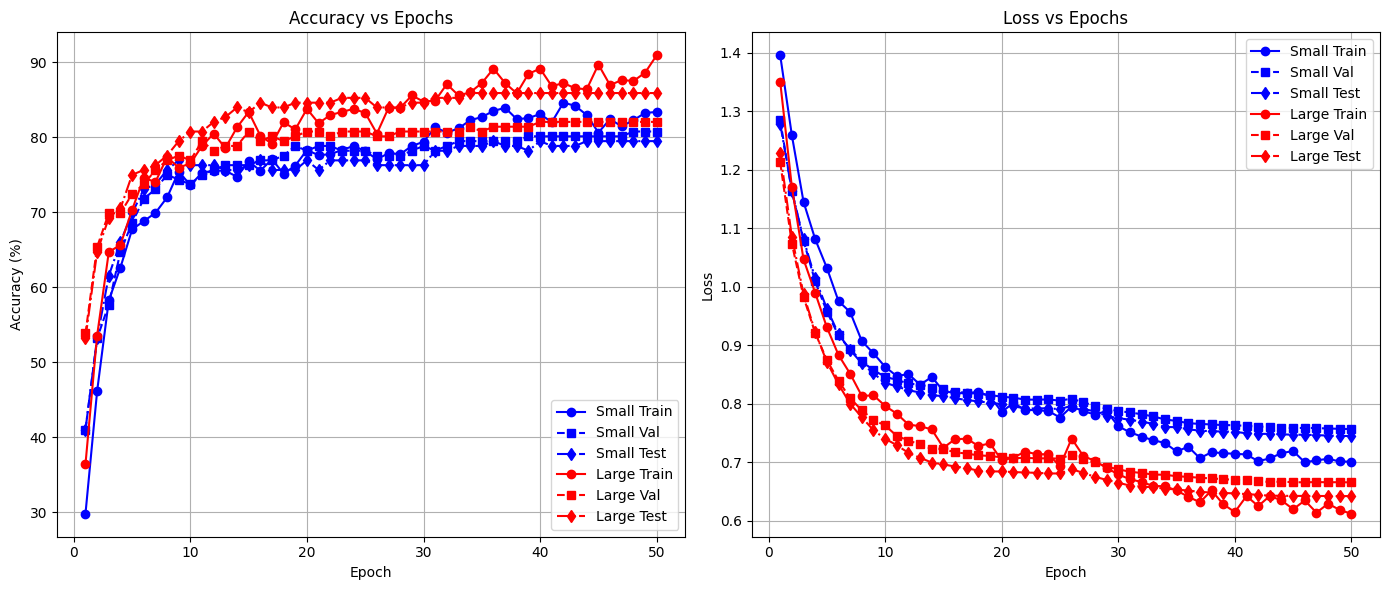


=== Confusion Matrix for MobileNetV3-Small ===
[[30  4  2  3]
 [ 4 35  0  0]
 [ 6  0 31  2]
 [ 6  1  4 28]]

=== Classification Report (Precision, Recall, F1) ===
              precision    recall  f1-score   support

    Inductor       0.65      0.77      0.71        39
    Resistor       0.88      0.90      0.89        39
 Transformer       0.84      0.79      0.82        39
    solenoid       0.85      0.72      0.78        39

    accuracy                           0.79       156
   macro avg       0.80      0.79      0.80       156
weighted avg       0.80      0.79      0.80       156


=== Confusion Matrix for MobileNetV3-Large ===
[[30  1  4  4]
 [ 2 36  1  0]
 [ 2  1 33  3]
 [ 1  0  3 35]]

=== Classification Report (Precision, Recall, F1) ===
              precision    recall  f1-score   support

    Inductor       0.86      0.77      0.81        39
    Resistor       0.95      0.92      0.94        39
 Transformer       0.80      0.85      0.82        39
    solenoid       0

W0629 14:44:29.961000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0629 14:44:29.963000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0629 14:44:29.965000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0629 14:44:29.966000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported: component_classifier_small.onnx


W0629 14:44:34.592000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0629 14:44:34.593000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0629 14:44:34.596000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0629 14:44:34.597000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported: component_classifier_large.onnx


In [3]:
# If you need confusion matrix and classification report, make sure scikit-learn is installed
# !pip install scikit-learn

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import onnxscript

# ============ Hyperparameters ============
DATA_ROOT = "/kaggle/input/datasets/chenkc064/electronic-components-4-classes/electrical_components"
BATCH_SIZE        = 32
IMG_SIZE          = 224
NUM_EPOCHS_stage1 = 25     # Number of epochs for stage 1 training
NUM_EPOCHS_stage2 = 25     # Number of epochs for stage 2 training
LR_stage1         = 5e-5   # Learning rate for stage 1
LR_stage2         = 1e-5   # Learning rate for stage 2
WEIGHT_DECAY      = 1e-4   # L2 regularization coefficient
PATIENCE          = 25      # Patience for early stopping (in epochs)
UNFREEZE_LAST_N   = 8      # Unfreeze the last N layers of the backbone

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============ Data Augmentation and Preprocessing ============
# Training transforms: random crop, horizontal flip, rotation, color jitter, random erasing
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.15)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])
# Validation/Test transforms: Resize + CenterCrop + Normalize
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ============ Datasets and DataLoaders ============
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"),  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes  # ['Inductor','Resistor','Transformer','solenoid']
num_classes = len(class_names)

print("Classes used:", class_names)

# ============ Model Creation Function ============
def create_model(model_type):
    """
    Creates a MobileNetV3 model according to model_type,
    freezes the backbone convolutional layers,
    and keeps only the final classifier trainable.
    """
    if model_type == "small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    else:
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)

    # Freeze all feature extraction layers in the backbone
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace the final classifier, adding dropout for regularization
    in_feat = model.classifier[3].in_features
    model.classifier[3] = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_feat, num_classes)
    )
    return model

# ============ Training Function ============
def train_model(model, num_epochs, lr):
    """
    Executes the training loop (can be used for Stage1 or Stage2):
    - model: the model with properly set requires_grad flags
    - num_epochs: number of iterations
    - lr: initial learning rate
    Returns the best model (based on validation accuracy) and training history.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # Optimize only the parameters that require gradients
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    history = {"train_acc":[], "train_loss":[], "val_acc":[], "val_loss":[],
               "test_acc":[], "test_loss":[]}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    print(f"\n=== Starting training (Epochs={num_epochs}, LR={lr}) ===")
    for epoch in range(1, num_epochs+1):
        # -- Training phase --
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100.0 * running_correct / total

        # -- Validation phase --
        model.eval()
        val_loss = 0.0; val_correct = 0; val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_loss /= val_total
        val_acc = 100.0 * val_correct / val_total

        # -- Test phase (for observation, not tuning) --
        test_loss = 0.0; test_correct = 0; test_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
        test_loss /= test_total
        test_acc = 100.0 * test_correct / test_total

        # Record results
        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_loss"].append(val_loss)
        history["test_acc"].append(test_acc)
        history["test_loss"].append(test_loss)

        print(f"Epoch {epoch:02d}/{num_epochs:02d} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")

        # Check for best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Update learning rate (based on validation accuracy)
        scheduler.step(val_acc)

        # Early stopping check
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping: no improvement for {PATIENCE} consecutive epochs, stopping training.")
            break

    # Load best weights
    model.load_state_dict(best_weights)
    return model, history

# ============ Small Model Training (MobileNetV3-Small) ============
# Stage1: Frozen backbone, train only classifier
small_model = create_model("small")
small_model, history_small_s1 = train_model(small_model, NUM_EPOCHS_stage1, LR_stage1)

# Stage2: Unfreeze last few layers for fine-tuning
# Unfreeze the last N layers of the backbone according to UNFREEZE_LAST_N
if UNFREEZE_LAST_N > 0:
    # Get all child modules from features
    children = list(small_model.features.children())
    # Unfreeze the last N sub-modules
    for layer in children[-UNFREEZE_LAST_N:]:
        for param in layer.parameters():
            param.requires_grad = True
# Move model back to GPU before training
small_model = small_model.to(DEVICE)
small_model, history_small_s2 = train_model(small_model, NUM_EPOCHS_stage2, LR_stage2)

# Combine Small model training history (Stage1 + Stage2)
small_train_acc = history_small_s1["train_acc"] + history_small_s2["train_acc"]
small_val_acc   = history_small_s1["val_acc"]   + history_small_s2["val_acc"]
small_test_acc  = history_small_s1["test_acc"]  + history_small_s2["test_acc"]
small_train_loss = history_small_s1["train_loss"] + history_small_s2["train_loss"]
small_val_loss   = history_small_s1["val_loss"]   + history_small_s2["val_loss"]
small_test_loss  = history_small_s1["test_loss"]  + history_small_s2["test_loss"]
small_epochs = range(1, len(small_train_acc) + 1)

# ============ Large Model Training (MobileNetV3-Large) ============
large_model = create_model("large")
large_model, history_large_s1 = train_model(large_model, NUM_EPOCHS_stage1, LR_stage1)

if UNFREEZE_LAST_N > 0:
    children = list(large_model.features.children())
    for layer in children[-UNFREEZE_LAST_N:]:
        for param in layer.parameters():
            param.requires_grad = True
large_model = large_model.to(DEVICE)
large_model, history_large_s2 = train_model(large_model, NUM_EPOCHS_stage2, LR_stage2)

large_train_acc = history_large_s1["train_acc"] + history_large_s2["train_acc"]
large_val_acc   = history_large_s1["val_acc"]   + history_large_s2["val_acc"]
large_test_acc  = history_large_s1["test_acc"]  + history_large_s2["test_acc"]
large_train_loss = history_large_s1["train_loss"] + history_large_s2["train_loss"]
large_val_loss   = history_large_s1["val_loss"]   + history_large_s2["val_loss"]
large_test_loss  = history_large_s1["test_loss"]  + history_large_s2["test_loss"]
large_epochs = range(1, len(large_train_acc) + 1)

# ============ Plot Training/Validation/Test Accuracy and Loss Curves ============
plt.figure(figsize=(14,6))

# Accuracy
plt.subplot(1,2,1)
plt.plot(small_epochs, small_train_acc, 'b-o', label='Small Train')
plt.plot(small_epochs, small_val_acc,   'b--s', label='Small Val')
plt.plot(small_epochs, small_test_acc,  'b-.d', label='Small Test')
plt.plot(large_epochs, large_train_acc, 'r-o', label='Large Train')
plt.plot(large_epochs, large_val_acc,   'r--s', label='Large Val')
plt.plot(large_epochs, large_test_acc,  'r-.d', label='Large Test')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(small_epochs, small_train_loss, 'b-o', label='Small Train')
plt.plot(small_epochs, small_val_loss,   'b--s', label='Small Val')
plt.plot(small_epochs, small_test_loss,  'b-.d', label='Small Test')
plt.plot(large_epochs, large_train_loss, 'r-o', label='Large Train')
plt.plot(large_epochs, large_val_loss,   'r--s', label='Large Val')
plt.plot(large_epochs, large_test_loss,  'r-.d', label='Large Test')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

# ============ Confusion Matrix and Classification Report ============
def evaluate_model(model, name):
    """
    Evaluates the model on the test set, prints confusion matrix and classification report.
    """
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    # Compute confusion matrix and classification metrics
    cm = confusion_matrix(all_labels, all_preds)
    print(f"\n=== Confusion Matrix for {name} ===")
    print(cm)
    print("\n=== Classification Report (Precision, Recall, F1) ===")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model(small_model, "MobileNetV3-Small")
evaluate_model(large_model, "MobileNetV3-Large")

# ============ Save Models and Export ONNX ============
# Move models to CPU before saving
for model, name in [(small_model, "small"), (large_model, "large")]:
    model = model.to("cpu")
    torch.save(model.state_dict(), f"component_classifier_{name}.pth")
    # Export ONNX model (dynamic batch size)
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    torch.onnx.export(model, dummy_input, f"component_classifier_{name}.onnx",
                      input_names=['input'], output_names=['output'],
                      #dynamic_shapes={ "input": {0: "batch"}, "output": {0: "batch"} },
                      opset_version=18,
                      dynamo=True)
    print(f"ONNX model exported: component_classifier_{name}.onnx")

#please install before running "TRL + PEFT + Unsloth core configuration"->"save adapter"->"Converted to Ollama's real GGUF (food)"

In [2]:
!pip install -U unsloth trl peft datasets accelerate

  Using cached trl-1.10.0-py3-none-any.whl.metadata (12 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)


In [3]:
!pip freeze > /kaggle/working/requirements-cloud-lock.txt

In [4]:
!nvidia-smi

Thu Aug 13 08:19:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# ============================================================
# Install minimal required packages
# ============================================================
# Unsloth must be imported before TRL / Transformers / PEFT.

%pip install -q -U unsloth datasets

# ============================================================
# Imports
# ============================================================
# Note: Unsloth must be imported first.

import unsloth
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

from trl import SFTConfig, SFTTrainer
import peft

import os
import re
import gc
import sys
import json
import math
import time
import random
import hashlib
import zipfile
import platform
import statistics
from pathlib import Path
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from tqdm.auto import tqdm
from IPython.display import FileLink, display

# ============================================================
# Production project settings
# ============================================================

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
MAX_LENGTH = 512
SEED = 3407

# Switch between:
# "small_model"
# "large_model"
VARIANT = "small_model"

# Production QLoRA hyperparameters
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

PER_DEVICE_TRAIN_BATCH = 2
PER_DEVICE_EVAL_BATCH = 2
GRADIENT_ACCUMULATION_STEPS = 8

NUM_EPOCHS = 2
LEARNING_RATE = 2e-4
WARMUP_STEPS = 5

# Fixed confidence threshold already encoded in all JSONL targets.
# Do not re-search or infer this threshold from validation targets.
PROJECT_CONFIDENCE_THRESHOLD = 0.70

# Inference settings
MAX_NEW_TOKENS = 256

# Test set has 156 samples; per‑sample inference is stable.
TEST_INFERENCE_LIMIT = None

# Reduce peak GPU / RAM pressure during GGUF saving.
GGUF_MAX_MEMORY_USAGE = 0.50

# ============================================================
# Output paths
# ============================================================

WORK_ROOT = Path("/kaggle/working")

ARTIFACT_ROOT = WORK_ROOT / f"qwen3_4b_electronics_{VARIANT}"

ADAPTER_DIR = ARTIFACT_ROOT / "adapter"
GGUF_DIR = ARTIFACT_ROOT / "gguf"
EVAL_DIR = ARTIFACT_ROOT / "evaluation"
PREPARED_DATA_DIR = ARTIFACT_ROOT / "prepared_data"

TRAINER_CACHE_DIR = WORK_ROOT / f"qwen3_4b_trainer_{VARIANT}"

REQUIREMENTS_FILE = ARTIFACT_ROOT / "requirements-cloud-lock.txt"
ENVIRONMENT_FILE = ARTIFACT_ROOT / "environment.json"
TRAINING_CONFIG_FILE = ARTIFACT_ROOT / "training_config.json"

FROZEN_THRESHOLD_FILE = ARTIFACT_ROOT / "confidence_threshold.json"

ZIP_PATH = WORK_ROOT / f"qwen3-4b-instruct-2507-{VARIANT}-artifacts.zip"

for d in [ARTIFACT_ROOT, ADAPTER_DIR, GGUF_DIR, EVAL_DIR, PREPARED_DATA_DIR, TRAINER_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# Fixed random seed
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Production model:", MODEL_NAME)
print("Vision model variant:", VARIANT)
print("Max sequence length:", MAX_LENGTH)
print("Artifact folder:", ARTIFACT_ROOT)

# ============================================================
# CUDA and GPU sanity check
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not detected. Enable GPU Accelerator in Kaggle Notebook Settings.")

GPU_COUNT = torch.cuda.device_count()

print("CUDA available: Yes")
print("PyTorch CUDA version:", torch.version.cuda)
print("Visible GPU count:", GPU_COUNT)

GPU_INFO = []
for i in range(GPU_COUNT):
    name = torch.cuda.get_device_name(i)
    cap = torch.cuda.get_device_capability(i)
    total_gb = torch.cuda.get_device_properties(i).total_memory / (1024 ** 3)
    GPU_INFO.append({"index": i, "name": name, "compute_capability": list(cap), "total_memory_gb": round(total_gb, 3)})
    print(f"GPU {i}: {name}, Compute Capability={cap}, VRAM={total_gb:.2f} GB")

# ============================================================
# Record package versions
# ============================================================

PKG_LIST = [
    "torch",
    "unsloth",
    "unsloth-zoo",
    "transformers",
    "trl",
    "peft",
    "datasets",
    "accelerate",
    "bitsandbytes",
    "safetensors",
    "huggingface-hub",
]

LOCKED = []
for pkg in PKG_LIST:
    try:
        ver = version(pkg)
        LOCKED.append(f"{pkg}=={ver}")
    except PackageNotFoundError:
        print(f"Warning: package version not found: {pkg}")

REQUIREMENTS_FILE.write_text("\n".join(LOCKED) + "\n", encoding="utf-8")

ENV_INFO = {
    "python": sys.version,
    "platform": platform.platform(),
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "visible_gpu_count": GPU_COUNT,
    "gpus": GPU_INFO,
    "model_name": MODEL_NAME,
    "model_variant": VARIANT,
    "seed": SEED,
}
ENVIRONMENT_FILE.write_text(json.dumps(ENV_INFO, ensure_ascii=False, indent=2), encoding="utf-8")

print("Package versions locked:")
print(REQUIREMENTS_FILE.read_text(encoding="utf-8"))

# ============================================================
# Automatically locate JSONL files
# ============================================================
# Do not hardcode any Kaggle username or private dataset path.

KAGGLE_INPUT_ROOT = Path("/kaggle/input")

def find_unique_file(filename: str) -> Path:
    candidates = sorted(KAGGLE_INPUT_ROOT.rglob(filename))
    if len(candidates) == 0:
        raise FileNotFoundError(f"Cannot find file: {filename}\nPlease ensure the electronics JSONL dataset is added to this notebook.")
    if len(candidates) > 1:
        raise RuntimeError(f"Multiple files found with name {filename}:\n" +
                           "\n".join(str(p) for p in candidates) +
                           "\nKeep only one dataset version.")
    return candidates[0]

TRAIN_JSONL = find_unique_file(f"electronics_train_{VARIANT}.jsonl")
VALIDATION_JSONL = find_unique_file(f"electronics_validation_{VARIANT}.jsonl")
TEST_JSONL = find_unique_file(f"electronics_test_{VARIANT}.jsonl")

print("Found training file:", TRAIN_JSONL.name)
print("Found validation file:", VALIDATION_JSONL.name)
print("Found test file:", TEST_JSONL.name)

# ============================================================
# Load 728 / 156 / 156 JSONL
# ============================================================

RAW_DATASET = load_dataset(
    "json",
    data_files={
        "train": str(TRAIN_JSONL),
        "validation": str(VALIDATION_JSONL),
        "test": str(TEST_JSONL),
    },
)

print("Train samples:", len(RAW_DATASET["train"]))
print("Validation samples:", len(RAW_DATASET["validation"]))
print("Test samples:", len(RAW_DATASET["test"]))

assert len(RAW_DATASET["train"]) == 728, "Train samples not 728."
assert len(RAW_DATASET["validation"]) == 156, "Validation samples not 156."
assert len(RAW_DATASET["test"]) == 156, "Test samples not 156."

# ============================================================
# Data structure and JSON Schema sanity check
# ============================================================

REQUIRED_FIELD_TYPES = {
    "identified_component": str,
    "predicted_component": str,
    "vision_confidence": (int, float),
    "confidence_threshold": (int, float),
    "requires_human_review": bool,
    "function": str,
    "operator_action": str,
    "limitation": str,
}

def get_role_content(example: dict, role: str) -> str:
    for msg in example.get("messages", []):
        if msg.get("role") == role:
            return str(msg.get("content", ""))
    raise ValueError(f"Role not found: {role}")

def strict_parse_json(text: str):
    try:
        obj = json.loads(text.strip())
        if not isinstance(obj, dict):
            return None
        return obj
    except Exception:
        return None

def check_schema(obj):
    if not isinstance(obj, dict):
        return False, "Assistant target is not a JSON object."
    # Required fields
    for field, expected_type in REQUIRED_FIELD_TYPES.items():
        if field not in obj:
            return False, f"Missing required field: {field}"
        value = obj[field]
        # Prevent bool being accepted as numeric
        if field in {
            "vision_confidence",
            "confidence_threshold",
        }:
            if isinstance(value, bool):
                return False, f"{field} must be numeric."
        if not isinstance(value, expected_type):
            return False, (
                f"Wrong type for {field}: "
                f"{type(value).__name__}"
            )
    confidence = float(
        obj["vision_confidence"]
    )
    threshold = float(
        obj["confidence_threshold"]
    )
    if not 0.0 <= confidence <= 1.0:
        return False, (
            "vision_confidence must be in [0, 1]."
        )
    if not 0.0 <= threshold <= 1.0:
        return False, (
            "confidence_threshold must be in [0, 1]."
        )
    expected_review = (
        confidence < threshold
    )
    # Check confidence gate
    if (
        obj["requires_human_review"]
        != expected_review
    ):
        return False, (
            "requires_human_review is inconsistent "
            "with the confidence threshold."
        )
    # Low-confidence case
    if expected_review:
        if (
            obj["identified_component"]
            != "uncertain"
        ):
            return False, (
                "Low-confidence result must use "
                "identified_component='uncertain'."
            )

    # Accepted case
    else:
        if (
            obj["identified_component"]
            != obj["predicted_component"]
        ):
            return False, (
                "For an accepted prediction, "
                "identified_component must equal "
                "predicted_component."
            )
    return True, ""

def schema_is_valid(obj) -> bool:
    """Return only the boolean part of check_schema() for metrics/inference."""
    ok, _ = check_schema(obj)
    return bool(ok)

def validate_single_example(example: dict) -> tuple[bool, str]:
    if "messages" not in example:
        return False, "Missing messages"

    msgs = example["messages"]
    if not isinstance(msgs, list):
        return False, "messages not a list"

    roles = [msg.get("role") for msg in msgs]
    for required in ["system", "user", "assistant"]:
        if required not in roles:
            return False, f"Missing role: {required}"

    assistant_text = get_role_content(example, "assistant")
    assistant_json = strict_parse_json(assistant_text)
    if assistant_json is None:
        return False, "assistant content is not valid JSON"

    # check_schema() returns (bool, reason).  Unpack it explicitly;
    # a non-empty tuple is always truthy in Python, even when its first item is False.
    schema_ok, schema_reason = check_schema(assistant_json)
    if not schema_ok:
        return False, f"assistant JSON schema error: {schema_reason}"

    return True, ""

DATA_ISSUES = []
for split in ["train", "validation", "test"]:
    for idx, example in enumerate(RAW_DATASET[split]):
        ok, reason = validate_single_example(example)
        if not ok:
            DATA_ISSUES.append({"split": split, "index": idx, "reason": reason})

print("Number of data structure issues:", len(DATA_ISSUES))
if DATA_ISSUES:
    print("First five issues:", DATA_ISSUES[:5])
    raise ValueError("JSONL schema check failed. Please correct the dataset.")
print("All JSONLs passed messages / JSON schema checks.")

# ============================================================
# Check for duplicate user messages across splits
# ============================================================

def text_hash(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

split_hashes = {}
for split in ["train", "validation", "test"]:
    split_hashes[split] = {text_hash(get_role_content(example, "user")) for example in RAW_DATASET[split]}

train_val_overlap = split_hashes["train"] & split_hashes["validation"]
train_test_overlap = split_hashes["train"] & split_hashes["test"]
val_test_overlap = split_hashes["validation"] & split_hashes["test"]

print("Train / Validation duplicate user messages:", len(train_val_overlap))
print("Train / Test duplicate user messages:", len(train_test_overlap))
print("Validation / Test duplicate user messages:", len(val_test_overlap))

# ============================================================
# Vision metadata extraction utilities
# ============================================================

STANDARD_CLASSES = {
    "inductor": "Inductor",
    "resistor": "Resistor",
    "transformer": "Transformer",
    "solenoid": "solenoid",
}

def normalize_class(value):
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None
    return STANDARD_CLASSES.get(s.lower(), s)

def recursive_find(obj, candidate_keys: set):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).lower() in candidate_keys:
                return v
        for v in obj.values():
            res = recursive_find(v, candidate_keys)
            if res is not None:
                return res
    elif isinstance(obj, list):
        for v in obj:
            res = recursive_find(v, candidate_keys)
            if res is not None:
                return res
    return None

def extract_first_match(text: str, patterns: list[str]):
    for pat in patterns:
        m = re.search(pat, text, flags=re.IGNORECASE | re.MULTILINE)
        if m:
            return m.group(1)
    return None

def extract_vision_metadata(example: dict) -> dict:
    user_text = get_role_content(example, "user")
    assistant_text = get_role_content(example, "assistant")
    assistant_json = strict_parse_json(assistant_text)

    # predicted class
    pred_class = recursive_find(example, {"predicted_class", "predicted_label"})
    if pred_class is None:
        pred_class = extract_first_match(user_text, [r"predicted_class\s*[:=]\s*([A-Za-z_-]+)", r"predicted_label\s*[:=]\s*([A-Za-z_-]+)"])
    pred_class = normalize_class(pred_class)

    # confidence
    conf = recursive_find(example, {"confidence", "vision_confidence"})
    if conf is None:
        conf = extract_first_match(user_text, [r"(?m)^\s*confidence\s*[:=]\s*([0-9]*\.?[0-9]+)", r"vision_confidence\s*[:=]\s*([0-9]*\.?[0-9]+)"])
    if conf is None and assistant_json:
        conf = assistant_json.get("vision_confidence")
    if conf is not None:
        conf = float(conf)

    # true / ground truth class
    true_label = recursive_find(example, {"true_label", "true_class", "ground_truth", "actual_class"})
    if true_label is None:
        true_label = extract_first_match(user_text, [r"true_label\s*[:=]\s*([A-Za-z_-]+)", r"true_class\s*[:=]\s*([A-Za-z_-]+)", r"ground_truth\s*[:=]\s*([A-Za-z_-]+)", r"actual_class\s*[:=]\s*([A-Za-z_-]+)"])
    true_label = normalize_class(true_label)

    # reference assistant policy
    ref_human_review = None
    ref_component = None
    if assistant_json:
        if isinstance(assistant_json.get("requires_human_review"), bool):
            ref_human_review = assistant_json["requires_human_review"]
        ref_component = normalize_class(assistant_json.get("identified_component"))

    return {
        "predicted_class": pred_class,
        "confidence": conf,
        "true_label": true_label,
        "reference_requires_human_review": ref_human_review,
        "reference_component": ref_component,
    }

ALL_METADATA = {}
for split in ["train", "validation", "test"]:
    ALL_METADATA[split] = [extract_vision_metadata(ex) for ex in RAW_DATASET[split]]
    missing_pred = sum(1 for d in ALL_METADATA[split] if d["predicted_class"] is None)
    missing_conf = sum(1 for d in ALL_METADATA[split] if d["confidence"] is None)
    missing_true = sum(1 for d in ALL_METADATA[split] if d["true_label"] is None)
    print(f"{split}: missing predicted_class={missing_pred}, missing confidence={missing_conf}, missing true_label={missing_true}")
    if missing_pred > 0:
        raise ValueError(f"{split} has samples that cannot parse predicted_class.")
    if missing_conf > 0:
        raise ValueError(f"{split} has samples that cannot parse confidence.")

# ============================================================
# Fixed confidence policy: verify threshold = 0.70
# ============================================================
# The uploaded JSONL files already encode confidence_threshold=0.70 and
# requires_human_review decisions.  Do NOT infer the threshold again from
# validation targets, and do NOT rewrite the assistant targets.

FROZEN_THRESHOLD = float(PROJECT_CONFIDENCE_THRESHOLD)
THRESHOLD_SELECTION_MODE = "predefined_dataset_policy"

POLICY_ISSUES = []
for split in ["train", "validation", "test"]:
    for idx, example in enumerate(RAW_DATASET[split]):
        assistant_json = strict_parse_json(get_role_content(example, "assistant"))
        if assistant_json is None:
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": "assistant content is not valid JSON",
            })
            continue

        confidence = float(assistant_json["vision_confidence"])
        threshold = float(assistant_json["confidence_threshold"])
        actual_review = assistant_json["requires_human_review"]
        expected_review = confidence < FROZEN_THRESHOLD

        if not np.isclose(threshold, FROZEN_THRESHOLD, atol=1e-12):
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": (
                    f"confidence_threshold={threshold}, "
                    f"expected={FROZEN_THRESHOLD}"
                ),
            })
        elif actual_review != expected_review:
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": (
                    f"requires_human_review={actual_review}, "
                    f"expected={expected_review}"
                ),
            })

print("Confidence policy issues:", len(POLICY_ISSUES))
if POLICY_ISSUES:
    print("First 20 policy issues:")
    for issue in POLICY_ISSUES[:20]:
        print(issue)
    raise ValueError("Dataset confidence policy validation failed.")

print(f"✅ All datasets follow the predefined confidence threshold = {FROZEN_THRESHOLD:.2f}.")

THRESHOLD_INFO = {
    "threshold": FROZEN_THRESHOLD,
    "selection_mode": THRESHOLD_SELECTION_MODE,
    "source": "predefined in the original JSONL dataset",
    "validation_samples": len(RAW_DATASET["validation"]),
    "test_used_for_selection": False,
}
FROZEN_THRESHOLD_FILE.write_text(
    json.dumps(THRESHOLD_INFO, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Frozen threshold info saved:", FROZEN_THRESHOLD_FILE.name)

# Keep the original, already validated 8-field assistant targets unchanged.
CORRECTED_DATASET = RAW_DATASET
print("Using original validated JSONL targets without rewriting.")

# ============================================================
# Save validated OpenAI-messages JSONL copies for artifacts
# ============================================================

def save_jsonl(data, output_path: Path):
    with output_path.open("w", encoding="utf-8") as f:
        for example in data:
            f.write(json.dumps(example, ensure_ascii=False) + "\n")

PREPARED_JSONL_PATHS = {}
for split in ["train", "validation", "test"]:
    out_path = PREPARED_DATA_DIR / f"electronics_{split}_{VARIANT}_validated.jsonl"
    save_jsonl(CORRECTED_DATASET[split], out_path)
    PREPARED_JSONL_PATHS[split] = out_path
    print(f"{split} validated JSONL copy: {out_path.name}")

# ============================================================
# Load Qwen3-4B-Instruct-2507
# ============================================================

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_LENGTH,
    dtype=None,          # Let Unsloth choose a compatible dtype.
    load_in_4bit=True,   # 4-bit QLoRA base model.
)

print("Base model loaded.")

# ============================================================
# Explicitly apply Qwen3 Instruct chat template
# ============================================================

tokenizer = get_chat_template(tokenizer, chat_template="qwen3-instruct")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Chat template set to qwen3-instruct.")
print("Padding token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

# ============================================================
# Attach PEFT LoRA
# ============================================================

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

print("PEFT LoRA adapter attached.")
model.print_trainable_parameters()

# ============================================================
# Convert messages → text
# ============================================================
# Training dataset gives SFTTrainer only a text field.
# No formatting_func is used.

def conversation_to_text(example: dict) -> dict:
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

TEXT_DATASET = CORRECTED_DATASET.map(conversation_to_text)

# Trainer keeps only the text column.
TRAIN_TEXT = TEXT_DATASET["train"].select_columns(["text"])
VAL_TEXT = TEXT_DATASET["validation"].select_columns(["text"])

print("messages → text complete.")
print("\nFirst training text preview:\n")
print(TRAIN_TEXT[0]["text"][:2000])

# ============================================================
# Token length analysis
# ============================================================

def count_tokens(text: str) -> int:
    tokens = tokenizer(text, add_special_tokens=False, truncation=False)["input_ids"]
    return len(tokens)

TOKEN_STATS = []
for split in ["train", "validation", "test"]:
    lengths = [count_tokens(example["text"]) for example in TEXT_DATASET[split]]
    over_limit = sum(1 for l in lengths if l > MAX_LENGTH)
    stats = {
        "split": split,
        "samples": len(lengths),
        "min_tokens": int(min(lengths)),
        "mean_tokens": float(np.mean(lengths)),
        "median_tokens": float(np.median(lengths)),
        "p95_tokens": float(np.percentile(lengths, 95)),
        "max_tokens": int(max(lengths)),
        "over_512": int(over_limit),
    }
    TOKEN_STATS.append(stats)

TOKEN_DF = pd.DataFrame(TOKEN_STATS)
display(TOKEN_DF)
TOKEN_DF.to_csv(EVAL_DIR / "token_length_analysis.csv", index=False)

total_over_limit = int(TOKEN_DF["over_512"].sum())
if total_over_limit > 0:
    raise RuntimeError(f"Found {total_over_limit} samples exceeding {MAX_LENGTH} tokens. Shorten prompts / targets before training.")
print(f"All samples do not exceed {MAX_LENGTH} tokens.")

# ============================================================
# Save production training configuration
# ============================================================

TRAINING_CONFIG = {
    "model_name": MODEL_NAME,
    "vision_model_variant": VARIANT,
    "dataset": {"train": 728, "validation": 156, "test": 156},
    "max_length": MAX_LENGTH,
    "quantization": {"load_in_4bit": True, "method": "QLoRA"},
    "lora": {
        "rank": LORA_RANK,
        "alpha": LORA_ALPHA,
        "dropout": LORA_DROPOUT,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    },
    "training": {
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH,
        "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "num_train_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "warmup_steps": WARMUP_STEPS,
        "lr_scheduler_type": "cosine",
        "seed": SEED,
    },
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "threshold_selection_mode": THRESHOLD_SELECTION_MODE,
    "gguf_quantization": "q4_k_m",
}
TRAINING_CONFIG_FILE.write_text(json.dumps(TRAINING_CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
print("Training config saved:", TRAINING_CONFIG_FILE.name)

# ============================================================
# SFTConfig
# ============================================================

TRAINING_ARGS = SFTConfig(
    output_dir=str(TRAINER_CACHE_DIR),

    # Dataset / sequence
    dataset_text_field="text",
    max_length=MAX_LENGTH,
    assistant_only_loss=False,   # Already full text sequences.
    packing=False,

    # Batch
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # Training
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    optim="adamw_8bit",

    # Logging
    logging_strategy="steps",
    logging_steps=5,

    # Kaggle/Jupyter stability: avoid NotebookProgressCallback state issues
    # when trainer.evaluate() is called after trainer.train().
    disable_tqdm=True,

    # Validation
    eval_strategy="steps",
    eval_steps=20,

    # Checkpoints
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Tesla T4
    fp16=True,
    bf16=False,

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    report_to="none",
)

print("SFTConfig created.")

# ============================================================
# Build SFTTrainer
# ============================================================
# No formatting_func passed.

trainer = SFTTrainer(
    model=model,
    args=TRAINING_ARGS,
    train_dataset=TRAIN_TEXT,
    eval_dataset=VAL_TEXT,
    processing_class=tokenizer,
)

print("SFTTrainer initialised successfully.")

# ============================================================
# Kaggle Cell: Multi-GPU / world_size check
# ============================================================

WORLD_SIZE = int(getattr(trainer.args, "world_size", 1))
TRAINER_VISIBLE_GPUS = int(getattr(trainer.args, "n_gpu", 1))

if WORLD_SIZE > 1:
    PARALLEL_FACTOR = WORLD_SIZE
else:
    PARALLEL_FACTOR = max(1, TRAINER_VISIBLE_GPUS)

ESTIMATED_GLOBAL_BATCH = PER_DEVICE_TRAIN_BATCH * GRADIENT_ACCUMULATION_STEPS * PARALLEL_FACTOR

print("Trainer world_size:", WORLD_SIZE)
print("Trainer n_gpu:", TRAINER_VISIBLE_GPUS)
print("Per‑device batch:", PER_DEVICE_TRAIN_BATCH)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Estimated global effective batch:", ESTIMATED_GLOBAL_BATCH)

# ============================================================
# Kaggle Cell: Final pre‑training sanity check
# ============================================================

print("Model:", MODEL_NAME)
print("Variant:", VARIANT)
print("Train:", len(TRAIN_TEXT))
print("Validation:", len(VAL_TEXT))
print("Test:", len(CORRECTED_DATASET["test"]))
print("Frozen confidence threshold:", FROZEN_THRESHOLD)
print("Max length:", MAX_LENGTH)
print("LoRA rank / alpha:", LORA_RANK, "/", LORA_ALPHA)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)
print("Pre‑training sanity check complete.")

# ============================================================
# Kaggle Cell: Run QLoRA SFT
# ============================================================

train_start = time.time()
train_result = trainer.train()
train_seconds = time.time() - train_start

print("QLoRA SFT completed.")
print(f"Training time: {train_seconds / 60:.2f} minutes")
print("Training metrics:")
print(train_result.metrics)

# ============================================================
# Kaggle Cell: Best model validation
# ============================================================
# IMPORTANT:
# SFTTrainer already preprocessed VAL_TEXT during initialization
# and stored the tokenized version in trainer.eval_dataset.
#
# Therefore DO NOT pass the raw VAL_TEXT again to evaluate().
# Passing raw VAL_TEXT would override trainer.eval_dataset and
# cause Transformers Trainer to see only the "text" column.

try:
    from transformers.utils.notebook import NotebookProgressCallback

    trainer.remove_callback(
        NotebookProgressCallback
    )

except Exception as callback_error:

    print(
        "NotebookProgressCallback removal skipped:",
        repr(callback_error)
    )

# ------------------------------------------------------------
# Optional diagnostic:
# Compare raw vs trainer-prepared evaluation dataset
# ------------------------------------------------------------

print("\nRaw VAL_TEXT columns:")
print(VAL_TEXT.column_names)

print("\nTrainer prepared eval_dataset columns:")

if hasattr(
    trainer.eval_dataset,
    "column_names"
):
    print(
        trainer.eval_dataset.column_names
    )
else:
    print(
        type(trainer.eval_dataset)
    )

# ------------------------------------------------------------
# Correct post-training validation
# ------------------------------------------------------------
# DO NOT use:
#
# trainer.evaluate(eval_dataset=VAL_TEXT)
#
# because VAL_TEXT is still raw text.
#
# Use trainer's already prepared eval_dataset instead.

validation_result = trainer.evaluate(
    metric_key_prefix="eval",
)


print(
    "\nBest checkpoint Validation results:"
)

print(
    json.dumps(
        validation_result,
        indent=2,
        ensure_ascii=False,
        default=str,
    )
)

# ============================================================
# Kaggle Cell: Save training logs
# ============================================================

TRAIN_LOG_FILE = EVAL_DIR / "training_log_history.json"
TRAIN_LOG_FILE.write_text(json.dumps(trainer.state.log_history, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

TRAIN_METRICS_FILE = EVAL_DIR / "training_metrics.json"
TRAIN_METRICS_FILE.write_text(json.dumps({
    "train_metrics": train_result.metrics,
    "validation_metrics": validation_result,
    "training_seconds": train_seconds,
    "best_model_checkpoint": trainer.state.best_model_checkpoint,
    "best_metric": trainer.state.best_metric,
    "world_size": WORLD_SIZE,
    "trainer_n_gpu": TRAINER_VISIBLE_GPUS,
    "estimated_global_effective_batch_size": ESTIMATED_GLOBAL_BATCH,
}, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

print("Training logs saved.")

# ============================================================
# Save best LoRA Adapter + Tokenizer
# ============================================================

ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
trainer.model.save_pretrained(str(ADAPTER_DIR), safe_serialization=True)
tokenizer.save_pretrained(str(ADAPTER_DIR))

ADAPTER_WEIGHTS = ADAPTER_DIR / "adapter_model.safetensors"
ADAPTER_CONFIG = ADAPTER_DIR / "adapter_config.json"
if not ADAPTER_WEIGHTS.exists():
    raise FileNotFoundError("adapter_model.safetensors not found.")
if not ADAPTER_CONFIG.exists():
    raise FileNotFoundError("adapter_config.json not found.")

print("LoRA Adapter saved successfully.")
print("Adapter weights:", ADAPTER_WEIGHTS.name)
print("Adapter config:", ADAPTER_CONFIG.name)
print("Adapter size:", f"{ADAPTER_WEIGHTS.stat().st_size / (1024 ** 2):.2f} MB")

# ============================================================
# Switch to inference mode
# ============================================================

FastLanguageModel.for_inference(trainer.model)
model = trainer.model
model.eval()
MODEL_DEVICE = next(p.device for p in model.parameters() if p.device.type != "meta")
print("Inference mode enabled.")
print("Primary model device:", MODEL_DEVICE)

# ============================================================
# Single‑sample generation function
# ============================================================

def build_inference_messages(example: dict) -> list[dict]:
    return [dict(msg) for msg in example["messages"] if msg.get("role") != "assistant"]

@torch.inference_mode()
def generate_single_response(messages: list[dict]) -> str:
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
    inputs = {k: v.to(MODEL_DEVICE) for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[1]
    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    new_tokens = outputs[0, input_len:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()

# ============================================================
# High‑confidence / Low‑confidence Smoke Test
# ============================================================

FIRST_SYSTEM = get_role_content(CORRECTED_DATASET["test"][0], "system")

HIGH_CONF = min(0.99, max(0.90, FROZEN_THRESHOLD + 0.15))
LOW_CONF = max(0.05, FROZEN_THRESHOLD - 0.20)

HIGH_MSG = [
    {"role": "system", "content": FIRST_SYSTEM},
    {"role": "user", "content": f"""
Vision model result:

predicted_class=Transformer
confidence={HIGH_CONF:.4f}
confidence_threshold={FROZEN_THRESHOLD:.4f}

class_probabilities:
Inductor=0.0300
Resistor=0.0200
Transformer={HIGH_CONF:.4f}
solenoid={max(0.0, 0.95 - HIGH_CONF):.4f}

Interpret this result for an operator.
""".strip()},
]

LOW_MSG = [
    {"role": "system", "content": FIRST_SYSTEM},
    {"role": "user", "content": f"""
Vision model result:

predicted_class=solenoid
confidence={LOW_CONF:.4f}
confidence_threshold={FROZEN_THRESHOLD:.4f}

class_probabilities:
Inductor=0.2500
Resistor=0.0500
Transformer=0.3100
solenoid={LOW_CONF:.4f}

Interpret this result for an operator.
""".strip()},
]

print("Running high‑confidence smoke test...")
high_response = generate_single_response(HIGH_MSG)
print("\nHigh‑confidence model response:\n")
print(high_response)
print("\nHigh‑confidence JSON valid:", strict_parse_json(high_response) is not None)

print("\nRunning low‑confidence smoke test...")
low_response = generate_single_response(LOW_MSG)
print("\nLow‑confidence model response:\n")
print(low_response)
low_json = strict_parse_json(low_response)
print("\nLow‑confidence JSON valid:", low_json is not None)
if low_json is not None:
    print("Low‑confidence requires_human_review:", low_json.get("requires_human_review"))

# ============================================================
# Smoke test automated validation
# ============================================================

HIGH_JSON = strict_parse_json(high_response)
LOW_JSON = strict_parse_json(low_response)

SMOKE_RESULT = {
    "frozen_threshold": FROZEN_THRESHOLD,
    "high_confidence": {
        "json_valid": HIGH_JSON is not None,
        "schema_compliance": schema_is_valid(HIGH_JSON) if HIGH_JSON else False,
        "expected_human_review": False,
        "actual_human_review": HIGH_JSON.get("requires_human_review") if HIGH_JSON else None,
    },
    "low_confidence": {
        "json_valid": LOW_JSON is not None,
        "schema_compliance": schema_is_valid(LOW_JSON) if LOW_JSON else False,
        "expected_human_review": True,
        "actual_human_review": LOW_JSON.get("requires_human_review") if LOW_JSON else None,
    },
}

SMOKE_FILE = EVAL_DIR / "smoke_test_results.json"
SMOKE_FILE.write_text(json.dumps(SMOKE_RESULT, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(SMOKE_RESULT, ensure_ascii=False, indent=2))

# ============================================================
# Full Test set inference
# ============================================================

test_data = CORRECTED_DATASET["test"]
if TEST_INFERENCE_LIMIT is None:
    num_test = len(test_data)
else:
    num_test = min(TEST_INFERENCE_LIMIT, len(test_data))

print("Test samples to infer:", num_test)

TEST_ROWS = []
infer_start = time.time()

for idx in tqdm(range(num_test), desc="Test inference"):
    example = test_data[idx]
    meta = extract_vision_metadata(example)
    inference_msgs = build_inference_messages(example)
    generated_text = generate_single_response(inference_msgs)
    generated_json = strict_parse_json(generated_text)
    json_valid = generated_json is not None
    schema_ok = schema_is_valid(generated_json) if json_valid else False
    expected_human = meta["confidence"] < FROZEN_THRESHOLD

    if json_valid:
        actual_human = generated_json.get("requires_human_review")
        generated_component = normalize_class(generated_json.get("identified_component"))
    else:
        actual_human = None
        generated_component = None

    policy_correct = json_valid and isinstance(actual_human, bool) and actual_human == expected_human

    # Selective accuracy reference
    if meta["true_label"] is not None:
        selective_ref = meta["true_label"]
        selective_mode = "true_label"
    else:
        selective_ref = meta["predicted_class"]
        selective_mode = "vision_prediction_fallback"

    auto_accepted = json_valid and actual_human is False
    accepted_and_correct = auto_accepted and generated_component == selective_ref

    TEST_ROWS.append({
        "index": idx,
        "predicted_class": meta["predicted_class"],
        "true_label": meta["true_label"],
        "confidence": meta["confidence"],
        "frozen_threshold": FROZEN_THRESHOLD,
        "expected_human_review": expected_human,
        "generated_text": generated_text,
        "json_valid": json_valid,
        "schema_compliance": schema_ok,
        "generated_requires_human_review": actual_human,
        "confidence_policy_correct": policy_correct,
        "generated_identified_component": generated_component,
        "selective_accuracy_reference": selective_ref,
        "selective_accuracy_reference_mode": selective_mode,
        "automatically_accepted": auto_accepted,
        "accepted_and_correct": accepted_and_correct,
    })

infer_seconds = time.time() - infer_start
print(f"Test inference completed in {infer_seconds / 60:.2f} minutes")
print(f"Average per sample: {infer_seconds / num_test:.3f} seconds")

# ============================================================
# Compute official Test metrics
# ============================================================

total = len(TEST_ROWS)
json_valid_count = sum(r["json_valid"] for r in TEST_ROWS)
schema_ok_count = sum(r["schema_compliance"] for r in TEST_ROWS)
policy_correct_count = sum(r["confidence_policy_correct"] for r in TEST_ROWS)

accepted_rows = [r for r in TEST_ROWS if r["automatically_accepted"]]
accepted_count = len(accepted_rows)
accepted_correct_count = sum(r["accepted_and_correct"] for r in accepted_rows)

json_valid_rate = json_valid_count / total
schema_rate = schema_ok_count / total
policy_accuracy = policy_correct_count / total
coverage = accepted_count / total
selective_accuracy = accepted_correct_count / accepted_count if accepted_count > 0 else None

has_full_true_labels = all(r["true_label"] is not None for r in TEST_ROWS)
reference_note = "true_label" if has_full_true_labels else "vision_prediction_fallback"

TEST_METRICS = {
    "samples": total,
    "json_valid_rate": json_valid_rate,
    "schema_compliance_rate": schema_rate,
    "confidence_policy_accuracy": policy_accuracy,
    "selective_accuracy": selective_accuracy,
    "coverage": coverage,
    "automatically_accepted_samples": accepted_count,
    "accepted_and_correct_samples": accepted_correct_count,
    "selective_accuracy_reference_mode": reference_note,
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "threshold_selection_mode": THRESHOLD_SELECTION_MODE,
    "total_inference_seconds": infer_seconds,
    "mean_seconds_per_sample": infer_seconds / total,
}

print("Official Test evaluation results:\n")
print(json.dumps(TEST_METRICS, ensure_ascii=False, indent=2))

# ============================================================
# Save Test results
# ============================================================

TEST_METRICS_FILE = EVAL_DIR / "test_metrics.json"
TEST_PREDICTIONS_FILE = EVAL_DIR / "test_predictions.jsonl"

TEST_METRICS_FILE.write_text(json.dumps(TEST_METRICS, ensure_ascii=False, indent=2), encoding="utf-8")

with TEST_PREDICTIONS_FILE.open("w", encoding="utf-8") as f:
    for row in TEST_ROWS:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Test metrics:", TEST_METRICS_FILE.name)
print("Test predictions:", TEST_PREDICTIONS_FILE.name)

# ============================================================
# Generate human‑readable evaluation table
# ============================================================

EVAL_SUMMARY = pd.DataFrame([
    {"Metric": "JSON Validity Rate", "Value": json_valid_rate},
    {"Metric": "Schema Compliance", "Value": schema_rate},
    {"Metric": "Confidence Policy Accuracy", "Value": policy_accuracy},
    {"Metric": "Selective Accuracy", "Value": selective_accuracy},
    {"Metric": "Coverage", "Value": coverage},
])
display(EVAL_SUMMARY)
EVAL_SUMMARY.to_csv(EVAL_DIR / "test_metrics_summary.csv", index=False)

# ============================================================
# Clean up GPU memory
# ============================================================

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Starting Q4_K_M GGUF export.")

# ============================================================
# Export merged Q4_K_M GGUF
# ============================================================

print("Starting Q4_K_M GGUF export.")

# Important:
# Current Unsloth may create:
#
#   <save_directory>_gguf/
#
# instead of putting the .gguf directly inside
# <save_directory>.
#
# Therefore always capture the return value.

gguf_export_result = model.save_pretrained_gguf(
    str(GGUF_DIR),
    tokenizer=tokenizer,
    quantization_method="q4_k_m",
    maximum_memory_usage=GGUF_MAX_MEMORY_USAGE,
)

print("\nGGUF export call completed.")

print("\nUnsloth export result:")
print(gguf_export_result)

# ============================================================
# Resolve actual GGUF output paths
# ============================================================

all_gguf = []

# ------------------------------------------------------------
# Preferred path:
# Current Unsloth returns a dict containing gguf_files and
# gguf_directory.
# ------------------------------------------------------------

if isinstance(
    gguf_export_result,
    dict,
):

    returned_files = (
        gguf_export_result.get(
            "gguf_files",
            [],
        )
        or []
    )

    for file_path in returned_files:
        p = Path(file_path)
        if p.exists():
            all_gguf.append(p)


    returned_directory = (
        gguf_export_result.get(
            "gguf_directory"
        )
    )

    if returned_directory:
        returned_directory = Path(
            returned_directory
        )
        if returned_directory.exists():
            for p in returned_directory.rglob(
                "*.gguf"
            ):
                if p not in all_gguf:
                    all_gguf.append(p)

# ------------------------------------------------------------
# Compatibility fallback:
# Search expected Unsloth directory.
#
# Current Unsloth commonly uses:
#
#   f"{save_directory}_gguf"
# ------------------------------------------------------------

if not all_gguf:
    unsloth_gguf_dir = Path(
        str(GGUF_DIR) + "_gguf"
    )
    if unsloth_gguf_dir.exists():
        all_gguf.extend(
            sorted(
                unsloth_gguf_dir.rglob(
                    "*.gguf"
                )
            )
        )

# ------------------------------------------------------------
# Final defensive fallback
# ------------------------------------------------------------

if not all_gguf:
    all_gguf.extend(
        sorted(
            ARTIFACT_ROOT.rglob(
                "*.gguf"
            )
        )
    )

# Remove duplicates
all_gguf = sorted(
    set(all_gguf),
    key=lambda p: str(p),
)

if not all_gguf:
    print("\nDirectory diagnostic:")
    for p in sorted(
        ARTIFACT_ROOT.rglob("*")
    ):
        if p.is_file():
            print(
                p.relative_to(
                    ARTIFACT_ROOT
                )
            )
    raise FileNotFoundError(
        "GGUF export returned successfully, "
        "but no .gguf file could be located."
    )

# ============================================================
# Select Q4_K_M artifact
# ============================================================

q4_candidates = [
    p
    for p in all_gguf
    if (
        "q4_k_m" in p.name.lower()
        or
        "q4-k-m" in p.name.lower()
    )
]

if q4_candidates:
    official_gguf = max(
        q4_candidates,
        key=lambda p: p.stat().st_size,
    )
    
else:
    print(
        "Warning: no filename explicitly "
        "contains Q4_K_M."
    )
    official_gguf = max(
        all_gguf,
        key=lambda p: p.stat().st_size,
    )

# ============================================================
# IMPORTANT:
# Downstream Ollama / ZIP code should use the real directory.
# ============================================================

GGUF_DIR = official_gguf.parent

print("\nFound GGUF files:")

for p in all_gguf:
    print(
        f"  {p.name} "
        f"({p.stat().st_size / (1024 ** 3):.3f} GB)"
    )

print("\nOfficial GGUF used:")
print(official_gguf)

print("\nActual GGUF directory:")
print(GGUF_DIR)

print(
    "\nOfficial GGUF size:",
    f"{official_gguf.stat().st_size / (1024 ** 3):.3f} GB"
)

# ============================================================
# Create Ollama Modelfile
# ============================================================

MODELFILE_PATH = GGUF_DIR / "Modelfile"
MODELFILE_CONTENT = f"""FROM ./{official_gguf.name}

PARAMETER temperature 0
PARAMETER num_ctx 2048
PARAMETER num_predict {MAX_NEW_TOKENS}
"""
MODELFILE_PATH.write_text(MODELFILE_CONTENT, encoding="utf-8")
print("Ollama Modelfile:")
print(MODELFILE_PATH.read_text(encoding="utf-8"))

# ============================================================
# Create deployment instructions
# ============================================================

DEPLOY_FILE = GGUF_DIR / "OLLAMA_COMMANDS.txt"
DEPLOY_CONTENT = """Download this gguf folder to your local machine and run inside the folder:

ollama create electronics-qwen3-4b -f Modelfile

ollama run electronics-qwen3-4b

To expose as OpenAI‑compatible API:

ollama serve

Default endpoint:
http://localhost:11434/v1/chat/completions

Model name:
electronics-qwen3-4b
"""
DEPLOY_FILE.write_text(DEPLOY_CONTENT, encoding="utf-8")
print("Ollama deployment commands written:", DEPLOY_FILE.name)

# ============================================================
# Regenerate final requirements lock
# ============================================================

LOCKED = []
for pkg in PKG_LIST:
    try:
        ver = version(pkg)
        LOCKED.append(f"{pkg}=={ver}")
    except PackageNotFoundError:
        pass
REQUIREMENTS_FILE.write_text("\n".join(LOCKED) + "\n", encoding="utf-8")
print("Final requirements lock:")
print(REQUIREMENTS_FILE.read_text(encoding="utf-8"))

# ============================================================
# Create artifact manifest
# ============================================================

MANIFEST = {
    "model_name": MODEL_NAME,
    "model_variant": VARIANT,
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "adapter": "adapter/adapter_model.safetensors",
    "adapter_config": "adapter/adapter_config.json",
    "gguf": f"gguf/{official_gguf.name}",
    "ollama_modelfile": "gguf/Modelfile",
    "requirements": "requirements-cloud-lock.txt",
    "evaluation": {
        "test_metrics": "evaluation/test_metrics.json",
        "test_predictions": "evaluation/test_predictions.jsonl",
        "token_length_analysis": "evaluation/token_length_analysis.csv",
        "smoke_test": "evaluation/smoke_test_results.json",
    },
}
MANIFEST_FILE = ARTIFACT_ROOT / "artifact_manifest.json"
MANIFEST_FILE.write_text(json.dumps(MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print("Artifact manifest created.")

# ============================================================
# SHA256 integrity checksums
# ============================================================

def compute_sha256(file_path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    hasher = hashlib.sha256()
    with file_path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

FILES_TO_HASH = [ADAPTER_WEIGHTS, ADAPTER_CONFIG, official_gguf, FROZEN_THRESHOLD_FILE, TEST_METRICS_FILE, REQUIREMENTS_FILE, TRAINING_CONFIG_FILE]
SHA_ROWS = []
for path in tqdm(FILES_TO_HASH, desc="Computing SHA256"):
    SHA_ROWS.append((compute_sha256(path), str(path.relative_to(ARTIFACT_ROOT))))

SHA256_FILE = ARTIFACT_ROOT / "SHA256SUMS.txt"
SHA256_FILE.write_text("\n".join(f"{h}  {rel}" for h, rel in SHA_ROWS) + "\n", encoding="utf-8")
print("SHA256SUMS.txt created.")

# ============================================================
# Create ZIP archive (using ZIP_STORED for GGUF)
# ============================================================

FILES_TO_PACK = []
for path in ADAPTER_DIR.rglob("*"):
    if path.is_file():
        FILES_TO_PACK.append(path)

FILES_TO_PACK.extend([official_gguf, MODELFILE_PATH, DEPLOY_FILE])

for path in EVAL_DIR.rglob("*"):
    if path.is_file():
        FILES_TO_PACK.append(path)

for path in PREPARED_DATA_DIR.rglob("*.jsonl"):
    FILES_TO_PACK.append(path)

FILES_TO_PACK.extend([REQUIREMENTS_FILE, ENVIRONMENT_FILE, TRAINING_CONFIG_FILE, FROZEN_THRESHOLD_FILE, MANIFEST_FILE, SHA256_FILE])
FILES_TO_PACK = sorted(set(FILES_TO_PACK), key=lambda p: str(p))

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, mode="w", compression=zipfile.ZIP_STORED, allowZip64=True) as zf:
    for src in tqdm(FILES_TO_PACK, desc="Creating artifact ZIP"):
        rel = src.relative_to(ARTIFACT_ROOT)
        zf.write(src, arcname=str(rel))

print("Artifact ZIP created:", ZIP_PATH.name)
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024 ** 3):.3f} GB")

# ============================================================
# Final artifact sanity check
# ============================================================

CHECKLIST = {
    "LoRA adapter_model.safetensors": ADAPTER_WEIGHTS,
    "LoRA adapter_config.json": ADAPTER_CONFIG,
    "Frozen threshold": FROZEN_THRESHOLD_FILE,
    "Test metrics": TEST_METRICS_FILE,
    "Requirements": REQUIREMENTS_FILE,
    "Q4_K_M GGUF": official_gguf,
    "Ollama Modelfile": MODELFILE_PATH,
    "Artifact ZIP": ZIP_PATH,
}

all_ok = True
for name, path in CHECKLIST.items():
    exists = path.exists()
    all_ok = all_ok and exists
    if exists:
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✅ {name}: {size_mb:.2f} MB")
    else:
        print(f"❌ {name}: missing")

if not all_ok:
    raise RuntimeError("Some production artifacts were not generated successfully.")
print("\nAll production artifacts passed file existence checks.")

# ============================================================
# Display final evaluation results
# ============================================================

print("============================================================")
print("Qwen3-4B-Instruct-2507 QLoRA Production Results")
print("============================================================")
print("Model:", MODEL_NAME)
print("Vision variant:", VARIANT)
print("Frozen confidence threshold:", FROZEN_THRESHOLD)
print(f"JSON Validity Rate: {json_valid_rate:.4f}")
print(f"Schema Compliance: {schema_rate:.4f}")
print(f"Confidence Policy Accuracy: {policy_accuracy:.4f}")
if selective_accuracy is not None:
    print(f"Selective Accuracy: {selective_accuracy:.4f}")
else:
    print("Selective Accuracy: No automatically accepted samples")
print(f"Coverage: {coverage:.4f}")
print("Selective Accuracy reference mode:", reference_note)
print("Adapter:", ADAPTER_WEIGHTS.name)
print("GGUF:", official_gguf.name)
print("ZIP:", ZIP_PATH.name)
print("============================================================")

# ============================================================
# Ollama Local Import Instructions
# ============================================================
#
# After downloading and unzipping, enter the `gguf/` directory:
#
# ollama create electronics-qwen3-4b -f Modelfile
# ollama run electronics-qwen3-4b
#
# To expose via the OpenAI‑compatible endpoint:
#
# ollama serve
# Endpoint: http://localhost:11434/v1/chat/completions
#
# For C++ / LangGraph integration, call the above endpoint.
# Qwen official docs confirm Ollama provides OpenAI‑compatible API;
# Unsloth recommends keeping the same chat template as training.

# ============================================================
# Download Artifact ZIP
# ============================================================
print("Downloadable artifact:")
display(FileLink(str(ZIP_PATH)))

# ============================================================
# Kaggle Save Version
# ============================================================
# After running all cells, use "Save Version" in Kaggle to preserve the execution results.
#
# Final deliverable file:
# /kaggle/working/qwen3-4b-instruct-2507-<variant>-artifacts.zip
#
# The ZIP contains at least:
#   adapter/          (adapter_model.safetensors, config, tokenizer)
#   gguf/             (*.Q4_K_M.gguf, Modelfile, OLLAMA_COMMANDS.txt)
#   evaluation/       (all metrics and prediction files)
#   prepared_data/    (validated copies of the original 8-field JSONL)
#   confidence_threshold.json
#   training_config.json
#   environment.json
#   requirements-cloud-lock.txt
#   artifact_manifest.json
#   SHA256SUMS.txt
# ============================================================

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 MB 23.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train samples: 728
Validation samples: 156
Test samples: 156
Number of data structure issues: 0
All JSONLs passed messages / JSON schema checks.
Train / Validation duplicate user messages: 0
Train / Test duplicate user messages: 2
Validation / Test duplicate user messages: 0
train: missing predicted_class=0, missing confidence=0, missing true_label=728
validation: missing predicted_class=0, missing confidence=0, missing true_label=156
test: missing predicted_class=0, missing confidence=0, missing true_label=156
Confidence policy issues: 0
✅ All datasets follow the predefined confidence threshold = 0.70.
Frozen threshold info saved: confidence_threshold.json
Using original validated JSONL targets without rewriting.
train validated JSONL copy: electronics_train_small_model_validated.jsonl
validation validated JSONL copy: electronics_validation_small_model_validated.jsonl
test validated JSONL copy: electronics_test_small_model_validated.jsonl
==((====))==  Unsloth 2026.8.16: Fast Qwen3 pa

...

Computing SHA256:   0%|          | 0/7 [00:00<?, ?it/s]

SHA256SUMS.txt created.


Creating artifact ZIP:   0%|          | 0/25 [00:00<?, ?it/s]

Artifact ZIP created: qwen3-4b-instruct-2507-small_model-artifacts.zip
ZIP size: 2.399 GB
✅ LoRA adapter_model.safetensors: 63.06 MB
✅ LoRA adapter_config.json: 0.00 MB
✅ Frozen threshold: 0.00 MB
✅ Test metrics: 0.00 MB
✅ Requirements: 0.00 MB
✅ Q4_K_M GGUF: 2381.59 MB
✅ Ollama Modelfile: 0.00 MB
✅ Artifact ZIP: 2456.86 MB

All production artifacts passed file existence checks.
Qwen3-4B-Instruct-2507 QLoRA Production Results
Model: Qwen/Qwen3-4B-Instruct-2507
Vision variant: small_model
Frozen confidence threshold: 0.7
JSON Validity Rate: 1.0000
Schema Compliance: 1.0000
Confidence Policy Accuracy: 1.0000
Selective Accuracy: 1.0000
Coverage: 0.4295
Selective Accuracy reference mode: vision_prediction_fallback
Adapter: adapter_model.safetensors
GGUF: qwen3-4b-instruct-2507.Q4_K_M.gguf
ZIP: qwen3-4b-instruct-2507-small_model-artifacts.zip
Downloadable artifact:


/kaggle/working/qwen3-4b-instruct-2507-small_model-artifacts.zip

In [3]:
# ============================================================
# Install minimal required packages
# ============================================================
# Unsloth must be imported before TRL / Transformers / PEFT.

%pip install -q -U unsloth datasets

# ============================================================
# Imports
# ============================================================
# Note: Unsloth must be imported first.

import unsloth
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

from trl import SFTConfig, SFTTrainer
import peft

import os
import re
import gc
import sys
import json
import math
import time
import random
import hashlib
import zipfile
import platform
import statistics
from pathlib import Path
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from tqdm.auto import tqdm
from IPython.display import FileLink, display

# ============================================================
# Production project settings
# ============================================================

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
MAX_LENGTH = 512
SEED = 3407

# Switch between:
# "small_model"
# "large_model"
VARIANT = "large_model"

# Production QLoRA hyperparameters
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

PER_DEVICE_TRAIN_BATCH = 2
PER_DEVICE_EVAL_BATCH = 2
GRADIENT_ACCUMULATION_STEPS = 8

NUM_EPOCHS = 2
LEARNING_RATE = 2e-4
WARMUP_STEPS = 5

# Fixed confidence threshold already encoded in all JSONL targets.
# Do not re-search or infer this threshold from validation targets.
PROJECT_CONFIDENCE_THRESHOLD = 0.70

# Inference settings
MAX_NEW_TOKENS = 256

# Test set has 156 samples; per‑sample inference is stable.
TEST_INFERENCE_LIMIT = None

# Reduce peak GPU / RAM pressure during GGUF saving.
GGUF_MAX_MEMORY_USAGE = 0.50

# ============================================================
# Output paths
# ============================================================

WORK_ROOT = Path("/kaggle/working")

ARTIFACT_ROOT = WORK_ROOT / f"qwen3_4b_electronics_{VARIANT}"

ADAPTER_DIR = ARTIFACT_ROOT / "adapter"
GGUF_DIR = ARTIFACT_ROOT / "gguf"
EVAL_DIR = ARTIFACT_ROOT / "evaluation"
PREPARED_DATA_DIR = ARTIFACT_ROOT / "prepared_data"

TRAINER_CACHE_DIR = WORK_ROOT / f"qwen3_4b_trainer_{VARIANT}"

REQUIREMENTS_FILE = ARTIFACT_ROOT / "requirements-cloud-lock.txt"
ENVIRONMENT_FILE = ARTIFACT_ROOT / "environment.json"
TRAINING_CONFIG_FILE = ARTIFACT_ROOT / "training_config.json"

FROZEN_THRESHOLD_FILE = ARTIFACT_ROOT / "confidence_threshold.json"

ZIP_PATH = WORK_ROOT / f"qwen3-4b-instruct-2507-{VARIANT}-artifacts.zip"

for d in [ARTIFACT_ROOT, ADAPTER_DIR, GGUF_DIR, EVAL_DIR, PREPARED_DATA_DIR, TRAINER_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# Fixed random seed
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Production model:", MODEL_NAME)
print("Vision model variant:", VARIANT)
print("Max sequence length:", MAX_LENGTH)
print("Artifact folder:", ARTIFACT_ROOT)

# ============================================================
# CUDA and GPU sanity check
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not detected. Enable GPU Accelerator in Kaggle Notebook Settings.")

GPU_COUNT = torch.cuda.device_count()

print("CUDA available: Yes")
print("PyTorch CUDA version:", torch.version.cuda)
print("Visible GPU count:", GPU_COUNT)

GPU_INFO = []
for i in range(GPU_COUNT):
    name = torch.cuda.get_device_name(i)
    cap = torch.cuda.get_device_capability(i)
    total_gb = torch.cuda.get_device_properties(i).total_memory / (1024 ** 3)
    GPU_INFO.append({"index": i, "name": name, "compute_capability": list(cap), "total_memory_gb": round(total_gb, 3)})
    print(f"GPU {i}: {name}, Compute Capability={cap}, VRAM={total_gb:.2f} GB")

# ============================================================
# Record package versions
# ============================================================

PKG_LIST = [
    "torch",
    "unsloth",
    "unsloth-zoo",
    "transformers",
    "trl",
    "peft",
    "datasets",
    "accelerate",
    "bitsandbytes",
    "safetensors",
    "huggingface-hub",
]

LOCKED = []
for pkg in PKG_LIST:
    try:
        ver = version(pkg)
        LOCKED.append(f"{pkg}=={ver}")
    except PackageNotFoundError:
        print(f"Warning: package version not found: {pkg}")

REQUIREMENTS_FILE.write_text("\n".join(LOCKED) + "\n", encoding="utf-8")

ENV_INFO = {
    "python": sys.version,
    "platform": platform.platform(),
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "visible_gpu_count": GPU_COUNT,
    "gpus": GPU_INFO,
    "model_name": MODEL_NAME,
    "model_variant": VARIANT,
    "seed": SEED,
}
ENVIRONMENT_FILE.write_text(json.dumps(ENV_INFO, ensure_ascii=False, indent=2), encoding="utf-8")

print("Package versions locked:")
print(REQUIREMENTS_FILE.read_text(encoding="utf-8"))

# ============================================================
# Automatically locate JSONL files
# ============================================================
# Do not hardcode any Kaggle username or private dataset path.

KAGGLE_INPUT_ROOT = Path("/kaggle/input")

def find_unique_file(filename: str) -> Path:
    candidates = sorted(KAGGLE_INPUT_ROOT.rglob(filename))
    if len(candidates) == 0:
        raise FileNotFoundError(f"Cannot find file: {filename}\nPlease ensure the electronics JSONL dataset is added to this notebook.")
    if len(candidates) > 1:
        raise RuntimeError(f"Multiple files found with name {filename}:\n" +
                           "\n".join(str(p) for p in candidates) +
                           "\nKeep only one dataset version.")
    return candidates[0]

TRAIN_JSONL = find_unique_file(f"electronics_train_{VARIANT}.jsonl")
VALIDATION_JSONL = find_unique_file(f"electronics_validation_{VARIANT}.jsonl")
TEST_JSONL = find_unique_file(f"electronics_test_{VARIANT}.jsonl")

print("Found training file:", TRAIN_JSONL.name)
print("Found validation file:", VALIDATION_JSONL.name)
print("Found test file:", TEST_JSONL.name)

# ============================================================
# Load 728 / 156 / 156 JSONL
# ============================================================

RAW_DATASET = load_dataset(
    "json",
    data_files={
        "train": str(TRAIN_JSONL),
        "validation": str(VALIDATION_JSONL),
        "test": str(TEST_JSONL),
    },
)

print("Train samples:", len(RAW_DATASET["train"]))
print("Validation samples:", len(RAW_DATASET["validation"]))
print("Test samples:", len(RAW_DATASET["test"]))

assert len(RAW_DATASET["train"]) == 728, "Train samples not 728."
assert len(RAW_DATASET["validation"]) == 156, "Validation samples not 156."
assert len(RAW_DATASET["test"]) == 156, "Test samples not 156."

# ============================================================
# Data structure and JSON Schema sanity check
# ============================================================

REQUIRED_FIELD_TYPES = {
    "identified_component": str,
    "predicted_component": str,
    "vision_confidence": (int, float),
    "confidence_threshold": (int, float),
    "requires_human_review": bool,
    "function": str,
    "operator_action": str,
    "limitation": str,
}

def get_role_content(example: dict, role: str) -> str:
    for msg in example.get("messages", []):
        if msg.get("role") == role:
            return str(msg.get("content", ""))
    raise ValueError(f"Role not found: {role}")

def strict_parse_json(text: str):
    try:
        obj = json.loads(text.strip())
        if not isinstance(obj, dict):
            return None
        return obj
    except Exception:
        return None

def check_schema(obj):
    if not isinstance(obj, dict):
        return False, "Assistant target is not a JSON object."
    # Required fields
    for field, expected_type in REQUIRED_FIELD_TYPES.items():
        if field not in obj:
            return False, f"Missing required field: {field}"
        value = obj[field]
        # Prevent bool being accepted as numeric
        if field in {
            "vision_confidence",
            "confidence_threshold",
        }:
            if isinstance(value, bool):
                return False, f"{field} must be numeric."
        if not isinstance(value, expected_type):
            return False, (
                f"Wrong type for {field}: "
                f"{type(value).__name__}"
            )
    confidence = float(
        obj["vision_confidence"]
    )
    threshold = float(
        obj["confidence_threshold"]
    )
    if not 0.0 <= confidence <= 1.0:
        return False, (
            "vision_confidence must be in [0, 1]."
        )
    if not 0.0 <= threshold <= 1.0:
        return False, (
            "confidence_threshold must be in [0, 1]."
        )
    expected_review = (
        confidence < threshold
    )
    # Check confidence gate
    if (
        obj["requires_human_review"]
        != expected_review
    ):
        return False, (
            "requires_human_review is inconsistent "
            "with the confidence threshold."
        )
    # Low-confidence case
    if expected_review:
        if (
            obj["identified_component"]
            != "uncertain"
        ):
            return False, (
                "Low-confidence result must use "
                "identified_component='uncertain'."
            )

    # Accepted case
    else:
        if (
            obj["identified_component"]
            != obj["predicted_component"]
        ):
            return False, (
                "For an accepted prediction, "
                "identified_component must equal "
                "predicted_component."
            )
    return True, ""

def schema_is_valid(obj) -> bool:
    """Return only the boolean part of check_schema() for metrics/inference."""
    ok, _ = check_schema(obj)
    return bool(ok)

def validate_single_example(example: dict) -> tuple[bool, str]:
    if "messages" not in example:
        return False, "Missing messages"

    msgs = example["messages"]
    if not isinstance(msgs, list):
        return False, "messages not a list"

    roles = [msg.get("role") for msg in msgs]
    for required in ["system", "user", "assistant"]:
        if required not in roles:
            return False, f"Missing role: {required}"

    assistant_text = get_role_content(example, "assistant")
    assistant_json = strict_parse_json(assistant_text)
    if assistant_json is None:
        return False, "assistant content is not valid JSON"

    # check_schema() returns (bool, reason).  Unpack it explicitly;
    # a non-empty tuple is always truthy in Python, even when its first item is False.
    schema_ok, schema_reason = check_schema(assistant_json)
    if not schema_ok:
        return False, f"assistant JSON schema error: {schema_reason}"

    return True, ""

DATA_ISSUES = []
for split in ["train", "validation", "test"]:
    for idx, example in enumerate(RAW_DATASET[split]):
        ok, reason = validate_single_example(example)
        if not ok:
            DATA_ISSUES.append({"split": split, "index": idx, "reason": reason})

print("Number of data structure issues:", len(DATA_ISSUES))
if DATA_ISSUES:
    print("First five issues:", DATA_ISSUES[:5])
    raise ValueError("JSONL schema check failed. Please correct the dataset.")
print("All JSONLs passed messages / JSON schema checks.")

# ============================================================
# Check for duplicate user messages across splits
# ============================================================

def text_hash(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

split_hashes = {}
for split in ["train", "validation", "test"]:
    split_hashes[split] = {text_hash(get_role_content(example, "user")) for example in RAW_DATASET[split]}

train_val_overlap = split_hashes["train"] & split_hashes["validation"]
train_test_overlap = split_hashes["train"] & split_hashes["test"]
val_test_overlap = split_hashes["validation"] & split_hashes["test"]

print("Train / Validation duplicate user messages:", len(train_val_overlap))
print("Train / Test duplicate user messages:", len(train_test_overlap))
print("Validation / Test duplicate user messages:", len(val_test_overlap))

# ============================================================
# Vision metadata extraction utilities
# ============================================================

STANDARD_CLASSES = {
    "inductor": "Inductor",
    "resistor": "Resistor",
    "transformer": "Transformer",
    "solenoid": "solenoid",
}

def normalize_class(value):
    if value is None:
        return None
    s = str(value).strip()
    if not s:
        return None
    return STANDARD_CLASSES.get(s.lower(), s)

def recursive_find(obj, candidate_keys: set):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).lower() in candidate_keys:
                return v
        for v in obj.values():
            res = recursive_find(v, candidate_keys)
            if res is not None:
                return res
    elif isinstance(obj, list):
        for v in obj:
            res = recursive_find(v, candidate_keys)
            if res is not None:
                return res
    return None

def extract_first_match(text: str, patterns: list[str]):
    for pat in patterns:
        m = re.search(pat, text, flags=re.IGNORECASE | re.MULTILINE)
        if m:
            return m.group(1)
    return None

def extract_vision_metadata(example: dict) -> dict:
    user_text = get_role_content(example, "user")
    assistant_text = get_role_content(example, "assistant")
    assistant_json = strict_parse_json(assistant_text)

    # predicted class
    pred_class = recursive_find(example, {"predicted_class", "predicted_label"})
    if pred_class is None:
        pred_class = extract_first_match(user_text, [r"predicted_class\s*[:=]\s*([A-Za-z_-]+)", r"predicted_label\s*[:=]\s*([A-Za-z_-]+)"])
    pred_class = normalize_class(pred_class)

    # confidence
    conf = recursive_find(example, {"confidence", "vision_confidence"})
    if conf is None:
        conf = extract_first_match(user_text, [r"(?m)^\s*confidence\s*[:=]\s*([0-9]*\.?[0-9]+)", r"vision_confidence\s*[:=]\s*([0-9]*\.?[0-9]+)"])
    if conf is None and assistant_json:
        conf = assistant_json.get("vision_confidence")
    if conf is not None:
        conf = float(conf)

    # true / ground truth class
    true_label = recursive_find(example, {"true_label", "true_class", "ground_truth", "actual_class"})
    if true_label is None:
        true_label = extract_first_match(user_text, [r"true_label\s*[:=]\s*([A-Za-z_-]+)", r"true_class\s*[:=]\s*([A-Za-z_-]+)", r"ground_truth\s*[:=]\s*([A-Za-z_-]+)", r"actual_class\s*[:=]\s*([A-Za-z_-]+)"])
    true_label = normalize_class(true_label)

    # reference assistant policy
    ref_human_review = None
    ref_component = None
    if assistant_json:
        if isinstance(assistant_json.get("requires_human_review"), bool):
            ref_human_review = assistant_json["requires_human_review"]
        ref_component = normalize_class(assistant_json.get("identified_component"))

    return {
        "predicted_class": pred_class,
        "confidence": conf,
        "true_label": true_label,
        "reference_requires_human_review": ref_human_review,
        "reference_component": ref_component,
    }

ALL_METADATA = {}
for split in ["train", "validation", "test"]:
    ALL_METADATA[split] = [extract_vision_metadata(ex) for ex in RAW_DATASET[split]]
    missing_pred = sum(1 for d in ALL_METADATA[split] if d["predicted_class"] is None)
    missing_conf = sum(1 for d in ALL_METADATA[split] if d["confidence"] is None)
    missing_true = sum(1 for d in ALL_METADATA[split] if d["true_label"] is None)
    print(f"{split}: missing predicted_class={missing_pred}, missing confidence={missing_conf}, missing true_label={missing_true}")
    if missing_pred > 0:
        raise ValueError(f"{split} has samples that cannot parse predicted_class.")
    if missing_conf > 0:
        raise ValueError(f"{split} has samples that cannot parse confidence.")

# ============================================================
# Fixed confidence policy: verify threshold = 0.70
# ============================================================
# The uploaded JSONL files already encode confidence_threshold=0.70 and
# requires_human_review decisions.  Do NOT infer the threshold again from
# validation targets, and do NOT rewrite the assistant targets.

FROZEN_THRESHOLD = float(PROJECT_CONFIDENCE_THRESHOLD)
THRESHOLD_SELECTION_MODE = "predefined_dataset_policy"

POLICY_ISSUES = []
for split in ["train", "validation", "test"]:
    for idx, example in enumerate(RAW_DATASET[split]):
        assistant_json = strict_parse_json(get_role_content(example, "assistant"))
        if assistant_json is None:
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": "assistant content is not valid JSON",
            })
            continue

        confidence = float(assistant_json["vision_confidence"])
        threshold = float(assistant_json["confidence_threshold"])
        actual_review = assistant_json["requires_human_review"]
        expected_review = confidence < FROZEN_THRESHOLD

        if not np.isclose(threshold, FROZEN_THRESHOLD, atol=1e-12):
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": (
                    f"confidence_threshold={threshold}, "
                    f"expected={FROZEN_THRESHOLD}"
                ),
            })
        elif actual_review != expected_review:
            POLICY_ISSUES.append({
                "split": split,
                "index": idx,
                "reason": (
                    f"requires_human_review={actual_review}, "
                    f"expected={expected_review}"
                ),
            })

print("Confidence policy issues:", len(POLICY_ISSUES))
if POLICY_ISSUES:
    print("First 20 policy issues:")
    for issue in POLICY_ISSUES[:20]:
        print(issue)
    raise ValueError("Dataset confidence policy validation failed.")

print(f"✅ All datasets follow the predefined confidence threshold = {FROZEN_THRESHOLD:.2f}.")

THRESHOLD_INFO = {
    "threshold": FROZEN_THRESHOLD,
    "selection_mode": THRESHOLD_SELECTION_MODE,
    "source": "predefined in the original JSONL dataset",
    "validation_samples": len(RAW_DATASET["validation"]),
    "test_used_for_selection": False,
}
FROZEN_THRESHOLD_FILE.write_text(
    json.dumps(THRESHOLD_INFO, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Frozen threshold info saved:", FROZEN_THRESHOLD_FILE.name)

# Keep the original, already validated 8-field assistant targets unchanged.
CORRECTED_DATASET = RAW_DATASET
print("Using original validated JSONL targets without rewriting.")

# ============================================================
# Save validated OpenAI-messages JSONL copies for artifacts
# ============================================================

def save_jsonl(data, output_path: Path):
    with output_path.open("w", encoding="utf-8") as f:
        for example in data:
            f.write(json.dumps(example, ensure_ascii=False) + "\n")

PREPARED_JSONL_PATHS = {}
for split in ["train", "validation", "test"]:
    out_path = PREPARED_DATA_DIR / f"electronics_{split}_{VARIANT}_validated.jsonl"
    save_jsonl(CORRECTED_DATASET[split], out_path)
    PREPARED_JSONL_PATHS[split] = out_path
    print(f"{split} validated JSONL copy: {out_path.name}")

# ============================================================
# Load Qwen3-4B-Instruct-2507
# ============================================================

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_LENGTH,
    dtype=None,          # Let Unsloth choose a compatible dtype.
    load_in_4bit=True,   # 4-bit QLoRA base model.
)

print("Base model loaded.")

# ============================================================
# Explicitly apply Qwen3 Instruct chat template
# ============================================================

tokenizer = get_chat_template(tokenizer, chat_template="qwen3-instruct")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Chat template set to qwen3-instruct.")
print("Padding token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

# ============================================================
# Attach PEFT LoRA
# ============================================================

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

print("PEFT LoRA adapter attached.")
model.print_trainable_parameters()

# ============================================================
# Convert messages → text
# ============================================================
# Training dataset gives SFTTrainer only a text field.
# No formatting_func is used.

def conversation_to_text(example: dict) -> dict:
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

TEXT_DATASET = CORRECTED_DATASET.map(conversation_to_text)

# Trainer keeps only the text column.
TRAIN_TEXT = TEXT_DATASET["train"].select_columns(["text"])
VAL_TEXT = TEXT_DATASET["validation"].select_columns(["text"])

print("messages → text complete.")
print("\nFirst training text preview:\n")
print(TRAIN_TEXT[0]["text"][:2000])

# ============================================================
# Token length analysis
# ============================================================

def count_tokens(text: str) -> int:
    tokens = tokenizer(text, add_special_tokens=False, truncation=False)["input_ids"]
    return len(tokens)

TOKEN_STATS = []
for split in ["train", "validation", "test"]:
    lengths = [count_tokens(example["text"]) for example in TEXT_DATASET[split]]
    over_limit = sum(1 for l in lengths if l > MAX_LENGTH)
    stats = {
        "split": split,
        "samples": len(lengths),
        "min_tokens": int(min(lengths)),
        "mean_tokens": float(np.mean(lengths)),
        "median_tokens": float(np.median(lengths)),
        "p95_tokens": float(np.percentile(lengths, 95)),
        "max_tokens": int(max(lengths)),
        "over_512": int(over_limit),
    }
    TOKEN_STATS.append(stats)

TOKEN_DF = pd.DataFrame(TOKEN_STATS)
display(TOKEN_DF)
TOKEN_DF.to_csv(EVAL_DIR / "token_length_analysis.csv", index=False)

total_over_limit = int(TOKEN_DF["over_512"].sum())
if total_over_limit > 0:
    raise RuntimeError(f"Found {total_over_limit} samples exceeding {MAX_LENGTH} tokens. Shorten prompts / targets before training.")
print(f"All samples do not exceed {MAX_LENGTH} tokens.")

# ============================================================
# Save production training configuration
# ============================================================

TRAINING_CONFIG = {
    "model_name": MODEL_NAME,
    "vision_model_variant": VARIANT,
    "dataset": {"train": 728, "validation": 156, "test": 156},
    "max_length": MAX_LENGTH,
    "quantization": {"load_in_4bit": True, "method": "QLoRA"},
    "lora": {
        "rank": LORA_RANK,
        "alpha": LORA_ALPHA,
        "dropout": LORA_DROPOUT,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    },
    "training": {
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH,
        "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "num_train_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "warmup_steps": WARMUP_STEPS,
        "lr_scheduler_type": "cosine",
        "seed": SEED,
    },
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "threshold_selection_mode": THRESHOLD_SELECTION_MODE,
    "gguf_quantization": "q4_k_m",
}
TRAINING_CONFIG_FILE.write_text(json.dumps(TRAINING_CONFIG, ensure_ascii=False, indent=2), encoding="utf-8")
print("Training config saved:", TRAINING_CONFIG_FILE.name)

# ============================================================
# SFTConfig
# ============================================================

TRAINING_ARGS = SFTConfig(
    output_dir=str(TRAINER_CACHE_DIR),

    # Dataset / sequence
    dataset_text_field="text",
    max_length=MAX_LENGTH,
    assistant_only_loss=False,   # Already full text sequences.
    packing=False,

    # Batch
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # Training
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    optim="adamw_8bit",

    # Logging
    logging_strategy="steps",
    logging_steps=5,

    # Kaggle/Jupyter stability: avoid NotebookProgressCallback state issues
    # when trainer.evaluate() is called after trainer.train().
    disable_tqdm=True,

    # Validation
    eval_strategy="steps",
    eval_steps=20,

    # Checkpoints
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Tesla T4
    fp16=True,
    bf16=False,

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    report_to="none",
)

print("SFTConfig created.")

# ============================================================
# Build SFTTrainer
# ============================================================
# No formatting_func passed.

trainer = SFTTrainer(
    model=model,
    args=TRAINING_ARGS,
    train_dataset=TRAIN_TEXT,
    eval_dataset=VAL_TEXT,
    processing_class=tokenizer,
)

print("SFTTrainer initialised successfully.")

# ============================================================
# Kaggle Cell: Multi-GPU / world_size check
# ============================================================

WORLD_SIZE = int(getattr(trainer.args, "world_size", 1))
TRAINER_VISIBLE_GPUS = int(getattr(trainer.args, "n_gpu", 1))

if WORLD_SIZE > 1:
    PARALLEL_FACTOR = WORLD_SIZE
else:
    PARALLEL_FACTOR = max(1, TRAINER_VISIBLE_GPUS)

ESTIMATED_GLOBAL_BATCH = PER_DEVICE_TRAIN_BATCH * GRADIENT_ACCUMULATION_STEPS * PARALLEL_FACTOR

print("Trainer world_size:", WORLD_SIZE)
print("Trainer n_gpu:", TRAINER_VISIBLE_GPUS)
print("Per‑device batch:", PER_DEVICE_TRAIN_BATCH)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Estimated global effective batch:", ESTIMATED_GLOBAL_BATCH)

# ============================================================
# Kaggle Cell: Final pre‑training sanity check
# ============================================================

print("Model:", MODEL_NAME)
print("Variant:", VARIANT)
print("Train:", len(TRAIN_TEXT))
print("Validation:", len(VAL_TEXT))
print("Test:", len(CORRECTED_DATASET["test"]))
print("Frozen confidence threshold:", FROZEN_THRESHOLD)
print("Max length:", MAX_LENGTH)
print("LoRA rank / alpha:", LORA_RANK, "/", LORA_ALPHA)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)
print("Pre‑training sanity check complete.")

# ============================================================
# Kaggle Cell: Run QLoRA SFT
# ============================================================

train_start = time.time()
train_result = trainer.train()
train_seconds = time.time() - train_start

print("QLoRA SFT completed.")
print(f"Training time: {train_seconds / 60:.2f} minutes")
print("Training metrics:")
print(train_result.metrics)

# ============================================================
# Kaggle Cell: Best model validation
# ============================================================
# IMPORTANT:
# SFTTrainer already preprocessed VAL_TEXT during initialization
# and stored the tokenized version in trainer.eval_dataset.
#
# Therefore DO NOT pass the raw VAL_TEXT again to evaluate().
# Passing raw VAL_TEXT would override trainer.eval_dataset and
# cause Transformers Trainer to see only the "text" column.

try:
    from transformers.utils.notebook import NotebookProgressCallback

    trainer.remove_callback(
        NotebookProgressCallback
    )

except Exception as callback_error:

    print(
        "NotebookProgressCallback removal skipped:",
        repr(callback_error)
    )

# ------------------------------------------------------------
# Optional diagnostic:
# Compare raw vs trainer-prepared evaluation dataset
# ------------------------------------------------------------

print("\nRaw VAL_TEXT columns:")
print(VAL_TEXT.column_names)

print("\nTrainer prepared eval_dataset columns:")

if hasattr(
    trainer.eval_dataset,
    "column_names"
):
    print(
        trainer.eval_dataset.column_names
    )
else:
    print(
        type(trainer.eval_dataset)
    )

# ------------------------------------------------------------
# Correct post-training validation
# ------------------------------------------------------------
# DO NOT use:
#
# trainer.evaluate(eval_dataset=VAL_TEXT)
#
# because VAL_TEXT is still raw text.
#
# Use trainer's already prepared eval_dataset instead.

validation_result = trainer.evaluate(
    metric_key_prefix="eval",
)


print(
    "\nBest checkpoint Validation results:"
)

print(
    json.dumps(
        validation_result,
        indent=2,
        ensure_ascii=False,
        default=str,
    )
)

# ============================================================
# Kaggle Cell: Save training logs
# ============================================================

TRAIN_LOG_FILE = EVAL_DIR / "training_log_history.json"
TRAIN_LOG_FILE.write_text(json.dumps(trainer.state.log_history, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

TRAIN_METRICS_FILE = EVAL_DIR / "training_metrics.json"
TRAIN_METRICS_FILE.write_text(json.dumps({
    "train_metrics": train_result.metrics,
    "validation_metrics": validation_result,
    "training_seconds": train_seconds,
    "best_model_checkpoint": trainer.state.best_model_checkpoint,
    "best_metric": trainer.state.best_metric,
    "world_size": WORLD_SIZE,
    "trainer_n_gpu": TRAINER_VISIBLE_GPUS,
    "estimated_global_effective_batch_size": ESTIMATED_GLOBAL_BATCH,
}, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

print("Training logs saved.")

# ============================================================
# Save best LoRA Adapter + Tokenizer
# ============================================================

ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
trainer.model.save_pretrained(str(ADAPTER_DIR), safe_serialization=True)
tokenizer.save_pretrained(str(ADAPTER_DIR))

ADAPTER_WEIGHTS = ADAPTER_DIR / "adapter_model.safetensors"
ADAPTER_CONFIG = ADAPTER_DIR / "adapter_config.json"
if not ADAPTER_WEIGHTS.exists():
    raise FileNotFoundError("adapter_model.safetensors not found.")
if not ADAPTER_CONFIG.exists():
    raise FileNotFoundError("adapter_config.json not found.")

print("LoRA Adapter saved successfully.")
print("Adapter weights:", ADAPTER_WEIGHTS.name)
print("Adapter config:", ADAPTER_CONFIG.name)
print("Adapter size:", f"{ADAPTER_WEIGHTS.stat().st_size / (1024 ** 2):.2f} MB")

# ============================================================
# Switch to inference mode
# ============================================================

FastLanguageModel.for_inference(trainer.model)
model = trainer.model
model.eval()
MODEL_DEVICE = next(p.device for p in model.parameters() if p.device.type != "meta")
print("Inference mode enabled.")
print("Primary model device:", MODEL_DEVICE)

# ============================================================
# Single‑sample generation function
# ============================================================

def build_inference_messages(example: dict) -> list[dict]:
    return [dict(msg) for msg in example["messages"] if msg.get("role") != "assistant"]

@torch.inference_mode()
def generate_single_response(messages: list[dict]) -> str:
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
    inputs = {k: v.to(MODEL_DEVICE) for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[1]
    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    new_tokens = outputs[0, input_len:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()

# ============================================================
# High‑confidence / Low‑confidence Smoke Test
# ============================================================

FIRST_SYSTEM = get_role_content(CORRECTED_DATASET["test"][0], "system")

HIGH_CONF = min(0.99, max(0.90, FROZEN_THRESHOLD + 0.15))
LOW_CONF = max(0.05, FROZEN_THRESHOLD - 0.20)

HIGH_MSG = [
    {"role": "system", "content": FIRST_SYSTEM},
    {"role": "user", "content": f"""
Vision model result:

predicted_class=Transformer
confidence={HIGH_CONF:.4f}
confidence_threshold={FROZEN_THRESHOLD:.4f}

class_probabilities:
Inductor=0.0300
Resistor=0.0200
Transformer={HIGH_CONF:.4f}
solenoid={max(0.0, 0.95 - HIGH_CONF):.4f}

Interpret this result for an operator.
""".strip()},
]

LOW_MSG = [
    {"role": "system", "content": FIRST_SYSTEM},
    {"role": "user", "content": f"""
Vision model result:

predicted_class=solenoid
confidence={LOW_CONF:.4f}
confidence_threshold={FROZEN_THRESHOLD:.4f}

class_probabilities:
Inductor=0.2500
Resistor=0.0500
Transformer=0.3100
solenoid={LOW_CONF:.4f}

Interpret this result for an operator.
""".strip()},
]

print("Running high‑confidence smoke test...")
high_response = generate_single_response(HIGH_MSG)
print("\nHigh‑confidence model response:\n")
print(high_response)
print("\nHigh‑confidence JSON valid:", strict_parse_json(high_response) is not None)

print("\nRunning low‑confidence smoke test...")
low_response = generate_single_response(LOW_MSG)
print("\nLow‑confidence model response:\n")
print(low_response)
low_json = strict_parse_json(low_response)
print("\nLow‑confidence JSON valid:", low_json is not None)
if low_json is not None:
    print("Low‑confidence requires_human_review:", low_json.get("requires_human_review"))

# ============================================================
# Smoke test automated validation
# ============================================================

HIGH_JSON = strict_parse_json(high_response)
LOW_JSON = strict_parse_json(low_response)

SMOKE_RESULT = {
    "frozen_threshold": FROZEN_THRESHOLD,
    "high_confidence": {
        "json_valid": HIGH_JSON is not None,
        "schema_compliance": schema_is_valid(HIGH_JSON) if HIGH_JSON else False,
        "expected_human_review": False,
        "actual_human_review": HIGH_JSON.get("requires_human_review") if HIGH_JSON else None,
    },
    "low_confidence": {
        "json_valid": LOW_JSON is not None,
        "schema_compliance": schema_is_valid(LOW_JSON) if LOW_JSON else False,
        "expected_human_review": True,
        "actual_human_review": LOW_JSON.get("requires_human_review") if LOW_JSON else None,
    },
}

SMOKE_FILE = EVAL_DIR / "smoke_test_results.json"
SMOKE_FILE.write_text(json.dumps(SMOKE_RESULT, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(SMOKE_RESULT, ensure_ascii=False, indent=2))

# ============================================================
# Full Test set inference
# ============================================================

test_data = CORRECTED_DATASET["test"]
if TEST_INFERENCE_LIMIT is None:
    num_test = len(test_data)
else:
    num_test = min(TEST_INFERENCE_LIMIT, len(test_data))

print("Test samples to infer:", num_test)

TEST_ROWS = []
infer_start = time.time()

for idx in tqdm(range(num_test), desc="Test inference"):
    example = test_data[idx]
    meta = extract_vision_metadata(example)
    inference_msgs = build_inference_messages(example)
    generated_text = generate_single_response(inference_msgs)
    generated_json = strict_parse_json(generated_text)
    json_valid = generated_json is not None
    schema_ok = schema_is_valid(generated_json) if json_valid else False
    expected_human = meta["confidence"] < FROZEN_THRESHOLD

    if json_valid:
        actual_human = generated_json.get("requires_human_review")
        generated_component = normalize_class(generated_json.get("identified_component"))
    else:
        actual_human = None
        generated_component = None

    policy_correct = json_valid and isinstance(actual_human, bool) and actual_human == expected_human

    # Selective accuracy reference
    if meta["true_label"] is not None:
        selective_ref = meta["true_label"]
        selective_mode = "true_label"
    else:
        selective_ref = meta["predicted_class"]
        selective_mode = "vision_prediction_fallback"

    auto_accepted = json_valid and actual_human is False
    accepted_and_correct = auto_accepted and generated_component == selective_ref

    TEST_ROWS.append({
        "index": idx,
        "predicted_class": meta["predicted_class"],
        "true_label": meta["true_label"],
        "confidence": meta["confidence"],
        "frozen_threshold": FROZEN_THRESHOLD,
        "expected_human_review": expected_human,
        "generated_text": generated_text,
        "json_valid": json_valid,
        "schema_compliance": schema_ok,
        "generated_requires_human_review": actual_human,
        "confidence_policy_correct": policy_correct,
        "generated_identified_component": generated_component,
        "selective_accuracy_reference": selective_ref,
        "selective_accuracy_reference_mode": selective_mode,
        "automatically_accepted": auto_accepted,
        "accepted_and_correct": accepted_and_correct,
    })

infer_seconds = time.time() - infer_start
print(f"Test inference completed in {infer_seconds / 60:.2f} minutes")
print(f"Average per sample: {infer_seconds / num_test:.3f} seconds")

# ============================================================
# Compute official Test metrics
# ============================================================

total = len(TEST_ROWS)
json_valid_count = sum(r["json_valid"] for r in TEST_ROWS)
schema_ok_count = sum(r["schema_compliance"] for r in TEST_ROWS)
policy_correct_count = sum(r["confidence_policy_correct"] for r in TEST_ROWS)

accepted_rows = [r for r in TEST_ROWS if r["automatically_accepted"]]
accepted_count = len(accepted_rows)
accepted_correct_count = sum(r["accepted_and_correct"] for r in accepted_rows)

json_valid_rate = json_valid_count / total
schema_rate = schema_ok_count / total
policy_accuracy = policy_correct_count / total
coverage = accepted_count / total
selective_accuracy = accepted_correct_count / accepted_count if accepted_count > 0 else None

has_full_true_labels = all(r["true_label"] is not None for r in TEST_ROWS)
reference_note = "true_label" if has_full_true_labels else "vision_prediction_fallback"

TEST_METRICS = {
    "samples": total,
    "json_valid_rate": json_valid_rate,
    "schema_compliance_rate": schema_rate,
    "confidence_policy_accuracy": policy_accuracy,
    "selective_accuracy": selective_accuracy,
    "coverage": coverage,
    "automatically_accepted_samples": accepted_count,
    "accepted_and_correct_samples": accepted_correct_count,
    "selective_accuracy_reference_mode": reference_note,
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "threshold_selection_mode": THRESHOLD_SELECTION_MODE,
    "total_inference_seconds": infer_seconds,
    "mean_seconds_per_sample": infer_seconds / total,
}

print("Official Test evaluation results:\n")
print(json.dumps(TEST_METRICS, ensure_ascii=False, indent=2))

# ============================================================
# Save Test results
# ============================================================

TEST_METRICS_FILE = EVAL_DIR / "test_metrics.json"
TEST_PREDICTIONS_FILE = EVAL_DIR / "test_predictions.jsonl"

TEST_METRICS_FILE.write_text(json.dumps(TEST_METRICS, ensure_ascii=False, indent=2), encoding="utf-8")

with TEST_PREDICTIONS_FILE.open("w", encoding="utf-8") as f:
    for row in TEST_ROWS:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Test metrics:", TEST_METRICS_FILE.name)
print("Test predictions:", TEST_PREDICTIONS_FILE.name)

# ============================================================
# Generate human‑readable evaluation table
# ============================================================

EVAL_SUMMARY = pd.DataFrame([
    {"Metric": "JSON Validity Rate", "Value": json_valid_rate},
    {"Metric": "Schema Compliance", "Value": schema_rate},
    {"Metric": "Confidence Policy Accuracy", "Value": policy_accuracy},
    {"Metric": "Selective Accuracy", "Value": selective_accuracy},
    {"Metric": "Coverage", "Value": coverage},
])
display(EVAL_SUMMARY)
EVAL_SUMMARY.to_csv(EVAL_DIR / "test_metrics_summary.csv", index=False)

# ============================================================
# Clean up GPU memory
# ============================================================

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Starting Q4_K_M GGUF export.")

# ============================================================
# Export merged Q4_K_M GGUF
# ============================================================

print("Starting Q4_K_M GGUF export.")

# Important:
# Current Unsloth may create:
#
#   <save_directory>_gguf/
#
# instead of putting the .gguf directly inside
# <save_directory>.
#
# Therefore always capture the return value.

gguf_export_result = model.save_pretrained_gguf(
    str(GGUF_DIR),
    tokenizer=tokenizer,
    quantization_method="q4_k_m",
    maximum_memory_usage=GGUF_MAX_MEMORY_USAGE,
)

print("\nGGUF export call completed.")

print("\nUnsloth export result:")
print(gguf_export_result)

# ============================================================
# Resolve actual GGUF output paths
# ============================================================

all_gguf = []

# ------------------------------------------------------------
# Preferred path:
# Current Unsloth returns a dict containing gguf_files and
# gguf_directory.
# ------------------------------------------------------------

if isinstance(
    gguf_export_result,
    dict,
):

    returned_files = (
        gguf_export_result.get(
            "gguf_files",
            [],
        )
        or []
    )

    for file_path in returned_files:
        p = Path(file_path)
        if p.exists():
            all_gguf.append(p)


    returned_directory = (
        gguf_export_result.get(
            "gguf_directory"
        )
    )

    if returned_directory:
        returned_directory = Path(
            returned_directory
        )
        if returned_directory.exists():
            for p in returned_directory.rglob(
                "*.gguf"
            ):
                if p not in all_gguf:
                    all_gguf.append(p)

# ------------------------------------------------------------
# Compatibility fallback:
# Search expected Unsloth directory.
#
# Current Unsloth commonly uses:
#
#   f"{save_directory}_gguf"
# ------------------------------------------------------------

if not all_gguf:
    unsloth_gguf_dir = Path(
        str(GGUF_DIR) + "_gguf"
    )
    if unsloth_gguf_dir.exists():
        all_gguf.extend(
            sorted(
                unsloth_gguf_dir.rglob(
                    "*.gguf"
                )
            )
        )

# ------------------------------------------------------------
# Final defensive fallback
# ------------------------------------------------------------

if not all_gguf:
    all_gguf.extend(
        sorted(
            ARTIFACT_ROOT.rglob(
                "*.gguf"
            )
        )
    )

# Remove duplicates
all_gguf = sorted(
    set(all_gguf),
    key=lambda p: str(p),
)

if not all_gguf:
    print("\nDirectory diagnostic:")
    for p in sorted(
        ARTIFACT_ROOT.rglob("*")
    ):
        if p.is_file():
            print(
                p.relative_to(
                    ARTIFACT_ROOT
                )
            )
    raise FileNotFoundError(
        "GGUF export returned successfully, "
        "but no .gguf file could be located."
    )

# ============================================================
# Select Q4_K_M artifact
# ============================================================

q4_candidates = [
    p
    for p in all_gguf
    if (
        "q4_k_m" in p.name.lower()
        or
        "q4-k-m" in p.name.lower()
    )
]

if q4_candidates:
    official_gguf = max(
        q4_candidates,
        key=lambda p: p.stat().st_size,
    )
    
else:
    print(
        "Warning: no filename explicitly "
        "contains Q4_K_M."
    )
    official_gguf = max(
        all_gguf,
        key=lambda p: p.stat().st_size,
    )

# ============================================================
# IMPORTANT:
# Downstream Ollama / ZIP code should use the real directory.
# ============================================================

GGUF_DIR = official_gguf.parent

print("\nFound GGUF files:")

for p in all_gguf:
    print(
        f"  {p.name} "
        f"({p.stat().st_size / (1024 ** 3):.3f} GB)"
    )

print("\nOfficial GGUF used:")
print(official_gguf)

print("\nActual GGUF directory:")
print(GGUF_DIR)

print(
    "\nOfficial GGUF size:",
    f"{official_gguf.stat().st_size / (1024 ** 3):.3f} GB"
)

# ============================================================
# Create Ollama Modelfile
# ============================================================

MODELFILE_PATH = GGUF_DIR / "Modelfile"
MODELFILE_CONTENT = f"""FROM ./{official_gguf.name}

PARAMETER temperature 0
PARAMETER num_ctx 2048
PARAMETER num_predict {MAX_NEW_TOKENS}
"""
MODELFILE_PATH.write_text(MODELFILE_CONTENT, encoding="utf-8")
print("Ollama Modelfile:")
print(MODELFILE_PATH.read_text(encoding="utf-8"))

# ============================================================
# Create deployment instructions
# ============================================================

DEPLOY_FILE = GGUF_DIR / "OLLAMA_COMMANDS.txt"
DEPLOY_CONTENT = """Download this gguf folder to your local machine and run inside the folder:

ollama create electronics-qwen3-4b -f Modelfile

ollama run electronics-qwen3-4b

To expose as OpenAI‑compatible API:

ollama serve

Default endpoint:
http://localhost:11434/v1/chat/completions

Model name:
electronics-qwen3-4b
"""
DEPLOY_FILE.write_text(DEPLOY_CONTENT, encoding="utf-8")
print("Ollama deployment commands written:", DEPLOY_FILE.name)

# ============================================================
# Regenerate final requirements lock
# ============================================================

LOCKED = []
for pkg in PKG_LIST:
    try:
        ver = version(pkg)
        LOCKED.append(f"{pkg}=={ver}")
    except PackageNotFoundError:
        pass
REQUIREMENTS_FILE.write_text("\n".join(LOCKED) + "\n", encoding="utf-8")
print("Final requirements lock:")
print(REQUIREMENTS_FILE.read_text(encoding="utf-8"))

# ============================================================
# Create artifact manifest
# ============================================================

MANIFEST = {
    "model_name": MODEL_NAME,
    "model_variant": VARIANT,
    "frozen_confidence_threshold": FROZEN_THRESHOLD,
    "adapter": "adapter/adapter_model.safetensors",
    "adapter_config": "adapter/adapter_config.json",
    "gguf": f"gguf/{official_gguf.name}",
    "ollama_modelfile": "gguf/Modelfile",
    "requirements": "requirements-cloud-lock.txt",
    "evaluation": {
        "test_metrics": "evaluation/test_metrics.json",
        "test_predictions": "evaluation/test_predictions.jsonl",
        "token_length_analysis": "evaluation/token_length_analysis.csv",
        "smoke_test": "evaluation/smoke_test_results.json",
    },
}
MANIFEST_FILE = ARTIFACT_ROOT / "artifact_manifest.json"
MANIFEST_FILE.write_text(json.dumps(MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print("Artifact manifest created.")

# ============================================================
# SHA256 integrity checksums
# ============================================================

def compute_sha256(file_path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    hasher = hashlib.sha256()
    with file_path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

FILES_TO_HASH = [ADAPTER_WEIGHTS, ADAPTER_CONFIG, official_gguf, FROZEN_THRESHOLD_FILE, TEST_METRICS_FILE, REQUIREMENTS_FILE, TRAINING_CONFIG_FILE]
SHA_ROWS = []
for path in tqdm(FILES_TO_HASH, desc="Computing SHA256"):
    SHA_ROWS.append((compute_sha256(path), str(path.relative_to(ARTIFACT_ROOT))))

SHA256_FILE = ARTIFACT_ROOT / "SHA256SUMS.txt"
SHA256_FILE.write_text("\n".join(f"{h}  {rel}" for h, rel in SHA_ROWS) + "\n", encoding="utf-8")
print("SHA256SUMS.txt created.")

# ============================================================
# Create ZIP archive (using ZIP_STORED for GGUF)
# ============================================================

FILES_TO_PACK = []
for path in ADAPTER_DIR.rglob("*"):
    if path.is_file():
        FILES_TO_PACK.append(path)

FILES_TO_PACK.extend([official_gguf, MODELFILE_PATH, DEPLOY_FILE])

for path in EVAL_DIR.rglob("*"):
    if path.is_file():
        FILES_TO_PACK.append(path)

for path in PREPARED_DATA_DIR.rglob("*.jsonl"):
    FILES_TO_PACK.append(path)

FILES_TO_PACK.extend([REQUIREMENTS_FILE, ENVIRONMENT_FILE, TRAINING_CONFIG_FILE, FROZEN_THRESHOLD_FILE, MANIFEST_FILE, SHA256_FILE])
FILES_TO_PACK = sorted(set(FILES_TO_PACK), key=lambda p: str(p))

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, mode="w", compression=zipfile.ZIP_STORED, allowZip64=True) as zf:
    for src in tqdm(FILES_TO_PACK, desc="Creating artifact ZIP"):
        rel = src.relative_to(ARTIFACT_ROOT)
        zf.write(src, arcname=str(rel))

print("Artifact ZIP created:", ZIP_PATH.name)
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024 ** 3):.3f} GB")

# ============================================================
# Final artifact sanity check
# ============================================================

CHECKLIST = {
    "LoRA adapter_model.safetensors": ADAPTER_WEIGHTS,
    "LoRA adapter_config.json": ADAPTER_CONFIG,
    "Frozen threshold": FROZEN_THRESHOLD_FILE,
    "Test metrics": TEST_METRICS_FILE,
    "Requirements": REQUIREMENTS_FILE,
    "Q4_K_M GGUF": official_gguf,
    "Ollama Modelfile": MODELFILE_PATH,
    "Artifact ZIP": ZIP_PATH,
}

all_ok = True
for name, path in CHECKLIST.items():
    exists = path.exists()
    all_ok = all_ok and exists
    if exists:
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"✅ {name}: {size_mb:.2f} MB")
    else:
        print(f"❌ {name}: missing")

if not all_ok:
    raise RuntimeError("Some production artifacts were not generated successfully.")
print("\nAll production artifacts passed file existence checks.")

# ============================================================
# Display final evaluation results
# ============================================================

print("============================================================")
print("Qwen3-4B-Instruct-2507 QLoRA Production Results")
print("============================================================")
print("Model:", MODEL_NAME)
print("Vision variant:", VARIANT)
print("Frozen confidence threshold:", FROZEN_THRESHOLD)
print(f"JSON Validity Rate: {json_valid_rate:.4f}")
print(f"Schema Compliance: {schema_rate:.4f}")
print(f"Confidence Policy Accuracy: {policy_accuracy:.4f}")
if selective_accuracy is not None:
    print(f"Selective Accuracy: {selective_accuracy:.4f}")
else:
    print("Selective Accuracy: No automatically accepted samples")
print(f"Coverage: {coverage:.4f}")
print("Selective Accuracy reference mode:", reference_note)
print("Adapter:", ADAPTER_WEIGHTS.name)
print("GGUF:", official_gguf.name)
print("ZIP:", ZIP_PATH.name)
print("============================================================")

# ============================================================
# Ollama Local Import Instructions
# ============================================================
#
# After downloading and unzipping, enter the `gguf/` directory:
#
# ollama create electronics-qwen3-4b -f Modelfile
# ollama run electronics-qwen3-4b
#
# To expose via the OpenAI‑compatible endpoint:
#
# ollama serve
# Endpoint: http://localhost:11434/v1/chat/completions
#
# For C++ / LangGraph integration, call the above endpoint.
# Qwen official docs confirm Ollama provides OpenAI‑compatible API;
# Unsloth recommends keeping the same chat template as training.

# ============================================================
# Download Artifact ZIP
# ============================================================
print("Downloadable artifact:")
display(FileLink(str(ZIP_PATH)))

# ============================================================
# Kaggle Save Version
# ============================================================
# After running all cells, use "Save Version" in Kaggle to preserve the execution results.
#
# Final deliverable file:
# /kaggle/working/qwen3-4b-instruct-2507-<variant>-artifacts.zip
#
# The ZIP contains at least:
#   adapter/          (adapter_model.safetensors, config, tokenizer)
#   gguf/             (*.Q4_K_M.gguf, Modelfile, OLLAMA_COMMANDS.txt)
#   evaluation/       (all metrics and prediction files)
#   prepared_data/    (validated copies of the original 8-field JSONL)
#   confidence_threshold.json
#   training_config.json
#   environment.json
#   requirements-cloud-lock.txt
#   artifact_manifest.json
#   SHA256SUMS.txt
# ============================================================

Note: you may need to restart the kernel to use updated packages.
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Production model: Qwen/Qwen3-4B-Instruct-2507
Vision model variant: large_model
Max sequence length: 512
Artifact folder: /kaggle/working/qwen3_4b_electronics_large_model
CUDA available: Yes
PyTorch CUDA version: 12.8
Visible GPU count: 2
GPU 0: Tesla T4, Compute Capability=(7, 5), VRAM=14.56 GB
GPU 1: Tesla T4, Compute Capability=(7, 5), VRAM=14.56 GB
Package versions locked:
torch==2.10.0+cu128
unsloth==2026.8.16
unsloth-zoo==2026.8.11
transformers==5.5.0
trl==0.24.0
peft==0.20.0
datasets==4.3.0
accelerate==1.14.0
bitsandbytes==0.50.1
safetensors==0.7.0
huggingface-hub==1.11.0

Found training file: electronics_train_large_model.jsonl
Found validation file: electronics_validation_large_model.jsonl
Found test file: electronics_test_large_model.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train samples: 728
Validation samples: 156
Test samples: 156
Number of data structure issues: 0
All JSONLs passed messages / JSON schema checks.
Train / Validation duplicate user messages: 0
Train / Test duplicate user messages: 2
Validation / Test duplicate user messages: 0
train: missing predicted_class=0, missing confidence=0, missing true_label=728
validation: missing predicted_class=0, missing confidence=0, missing true_label=156
test: missing predicted_class=0, missing confidence=0, missing true_label=156
Confidence policy issues: 0
✅ All datasets follow the predefined confidence threshold = 0.70.
Frozen threshold info saved: confidence_threshold.json
Using original validated JSONL targets without rewriting.
train validated JSONL copy: electronics_train_large_model_validated.jsonl
validation validated JSONL copy: electronics_validation_large_model_validated.jsonl
test validated JSONL copy: electronics_test_large_model_validated.jsonl
==((====))==  Unsloth 2026.8.16: Fast Qwen3 pa

...

Computing SHA256:   0%|          | 0/7 [00:00<?, ?it/s]

SHA256SUMS.txt created.


Creating artifact ZIP:   0%|          | 0/25 [00:00<?, ?it/s]

Artifact ZIP created: qwen3-4b-instruct-2507-large_model-artifacts.zip
ZIP size: 2.399 GB
✅ LoRA adapter_model.safetensors: 63.06 MB
✅ LoRA adapter_config.json: 0.00 MB
✅ Frozen threshold: 0.00 MB
✅ Test metrics: 0.00 MB
✅ Requirements: 0.00 MB
✅ Q4_K_M GGUF: 2381.59 MB
✅ Ollama Modelfile: 0.00 MB
✅ Artifact ZIP: 2456.86 MB

All production artifacts passed file existence checks.
Qwen3-4B-Instruct-2507 QLoRA Production Results
Model: Qwen/Qwen3-4B-Instruct-2507
Vision variant: large_model
Frozen confidence threshold: 0.7
JSON Validity Rate: 1.0000
Schema Compliance: 1.0000
Confidence Policy Accuracy: 1.0000
Selective Accuracy: 1.0000
Coverage: 0.5897
Selective Accuracy reference mode: vision_prediction_fallback
Adapter: adapter_model.safetensors
GGUF: qwen3-4b-instruct-2507.Q4_K_M.gguf
ZIP: qwen3-4b-instruct-2507-large_model-artifacts.zip
Downloadable artifact:


/kaggle/working/qwen3-4b-instruct-2507-large_model-artifacts.zip